<a href="https://colab.research.google.com/github/heraclitus0/breast-cancer-prognosis-explainable-ml/blob/main/Clinical_Genomic_Predictive_Modeling_for_Breast_Cancer_Prognosis_An_Explainable_Machine_Learning_Approach_Using_the_METABRIC_Cohort.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#CELL 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries loaded.")
print(f"Pandas: {pd.__version__} | Numpy: {np.__version__}")

All libraries loaded.
Pandas: 2.2.2 | Numpy: 2.0.2


In [ ]:
#CELL 2 — Load data
from google.colab import drive

# Option A: if file is in Colab root (uploaded manually)
DATA_PATH = '/content/METABRIC_RNA_Mutation.csv'

# Option B: if file is in Google Drive (uncomment if needed)
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/METABRIC_RNA_Mutation.csv'

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully")
print(f"Shape      : {df.shape[0]} patients x {df.shape[1]} columns")
print(f"Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

# Quick sanity check — expected dimensions
assert df.shape[0] == 1904, f"Expected 1904 patients, got {df.shape[0]}"
assert df.shape[1] == 693,  f"Expected 693 columns, got {df.shape[1]}"

print("Sanity checks passed.")
print()
print("First 3 rows:")
df.head(3)

Dataset loaded successfully
Shape      : 1904 patients x 693 columns
Memory     : 26.0 MB

Sanity checks passed.

First 3 rows:


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,neoplasm_histologic_grade,her2_status_measured_by_snp6,her2_status,tumor_other_histologic_subtype,hormone_therapy,inferred_menopausal_state,integrative_cluster,primary_tumor_laterality,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,...,foxo1_mut,nt5e_mut,ccnd3_mut,nr3c1_mut,prkg1_mut,tbl1xr1_mut,frmd3_mut,smad2_mut,sgcd_mut,spaca1_mut,rasgef1b_mut,hist1h2bc_mut,nr2f1_mut,klrg1_mut,mbl2_mut,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.650,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.000,Positve,Positive,3.000,NEUTRAL,Negative,Ductal/NST,1,Post,4ER+,Right,10.000,NaN,6.044,IDC,140.500,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,43.190,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.000,Positve,Positive,3.000,NEUTRAL,Negative,Ductal/NST,1,Pre,4ER+,Right,0.000,2.000,4.020,IDC,84.633,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5,48.870,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.000,Positve,Positive,2.000,NEUTRAL,Negative,Ductal/NST,1,Pre,3,Right,1.000,2.000,4.030,IDC,163.700,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
#CELL 3 — Select clinical columns
CLINICAL_COLS = [
    'age_at_diagnosis',
    'type_of_breast_surgery',
    'cancer_type_detailed',
    'cellularity',
    'chemotherapy',
    'er_status',
    'her2_status',
    'hormone_therapy',
    'lymph_nodes_examined_positive',
    'mutation_count',
    'nottingham_prognostic_index',
    'pr_status',
    'radio_therapy',
    'tumor_size',
    'tumor_stage',              # will be dropped later — too many missing
    'overall_survival',         # TARGET
    'overall_survival_months',  # will be dropped later — survival time not a predictor
    'death_from_cancer',        # will be dropped later — data leakage
]

# Keep only columns that exist in the dataset
available = [c for c in CLINICAL_COLS if c in df.columns]
missing_cols = set(CLINICAL_COLS) - set(available)

if missing_cols:
    print(f"WARNING — these columns not found: {missing_cols}")
else:
    print("All expected columns found.")

clinical = df[available].copy()

print(f"Clinical subset shape : {clinical.shape}")
print(f"Columns selected      : {len(available)}")
print()
print("Column overview:")
print(clinical.dtypes.to_frame('dtype').join(
    clinical.isnull().sum().to_frame('missing')
))

All expected columns found.
Clinical subset shape : (1904, 18)
Columns selected      : 18

Column overview:
                                 dtype  missing
age_at_diagnosis               float64        0
type_of_breast_surgery          object       22
cancer_type_detailed            object       15
cellularity                     object       54
chemotherapy                     int64        0
er_status                       object        0
her2_status                     object        0
hormone_therapy                  int64        0
lymph_nodes_examined_positive  float64        0
mutation_count                 float64       45
nottingham_prognostic_index    float64        0
pr_status                       object        0
radio_therapy                    int64        0
tumor_size                     float64       20
tumor_stage                    float64      501
overall_survival                 int64        0
overall_survival_months        float64        0
death_from_cancer           

Missing value summary:
                        count    pct
tumor_stage               501 26.310
cellularity                54  2.840
mutation_count             45  2.360
type_of_breast_surgery     22  1.160
tumor_size                 20  1.050
cancer_type_detailed       15  0.790
death_from_cancer           1  0.050

Threshold            : 20.0%
Columns above thresh : ['tumor_stage']
Imputable columns    : ['cellularity', 'mutation_count', 'type_of_breast_surgery', 'tumor_size', 'cancer_type_detailed', 'death_from_cancer']


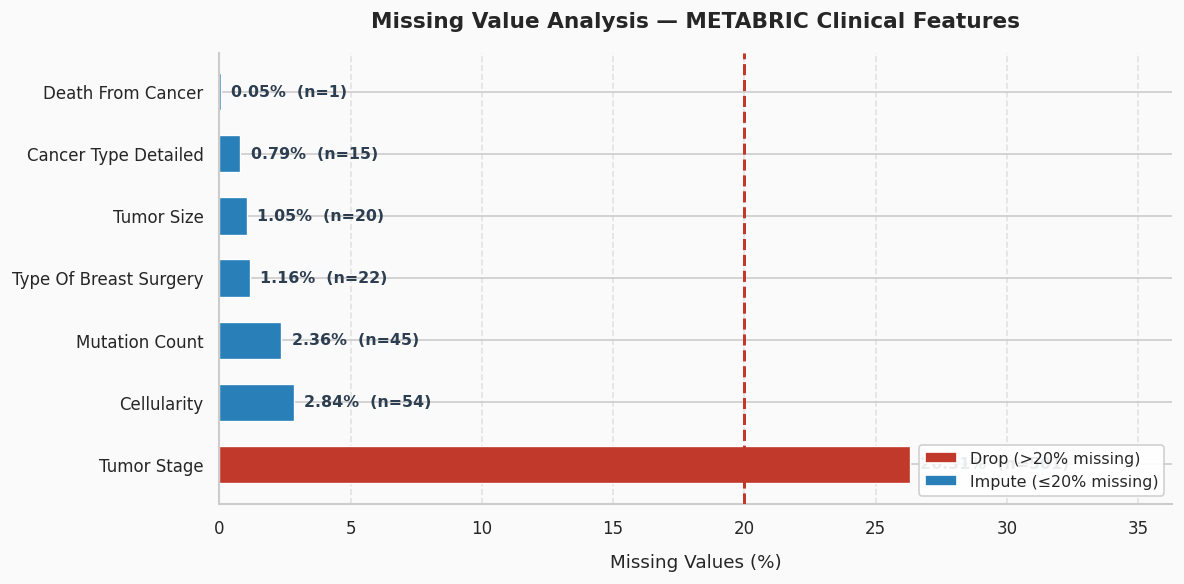

Saved: fig_missing_values.png


In [ ]:
#CELL 4 — Missing value analysis
MISSING_THRESHOLD = 20.0

missing = clinical.isnull().sum()
missing_pct = (missing / len(clinical) * 100).round(2)

missing_df = pd.DataFrame({
    'count': missing,
    'pct': missing_pct
}).query('count > 0').sort_values('pct', ascending=False)

print("Missing value summary:")
print(missing_df.to_string())
print()

to_drop_missing = missing_df[missing_df['pct'] > MISSING_THRESHOLD].index.tolist()
imputable = missing_df[missing_df['pct'] <= MISSING_THRESHOLD].index.tolist()

print(f"Threshold            : {MISSING_THRESHOLD}%")
print(f"Columns above thresh : {to_drop_missing}")
print(f"Imputable columns    : {imputable}")

# --- Publication quality figure ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Clean feature names for display
display_names = [name.replace('_', ' ').title()
                 for name in missing_df.index]
colors = ['#C0392B' if v > MISSING_THRESHOLD else '#2980B9'
          for v in missing_df['pct']]

bars = ax.barh(display_names, missing_df['pct'],
               color=colors, edgecolor='white',
               linewidth=0.8, height=0.6)

# Threshold line
ax.axvline(MISSING_THRESHOLD, color='#C0392B', linestyle='--',
           linewidth=1.8, label=f'Drop threshold ({MISSING_THRESHOLD}%)',
           zorder=5)

# Percentage labels — placed OUTSIDE bar to avoid overlap
for bar, (idx, row) in zip(bars, missing_df.iterrows()):
    bar_width = bar.get_width()
    ax.text(bar_width + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f'{row["pct"]}%  (n={int(row["count"])})',
            va='center', ha='left',
            fontsize=9.5, fontweight='bold',
            color='#2C3E50')

# Styling
ax.set_xlabel('Missing Values (%)', fontsize=11, labelpad=10)
ax.set_title('Missing Value Analysis — METABRIC Clinical Features',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, missing_df['pct'].max() + 10)  # extra space for labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(axis='both', labelsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

# Color legend for bar meaning
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C0392B', label='Drop (>20% missing)'),
    Patch(facecolor='#2980B9', label='Impute (≤20% missing)')
]
ax.legend(handles=legend_elements, fontsize=9.5,
          loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_missing_values.png")

=== Target: overall_survival ===
Alive (0) : 1103 patients (57.9%)
Died  (1) : 801 patients (42.1%)

Class imbalance ratio : 1.38:1
NOTE: Classes are reasonably balanced



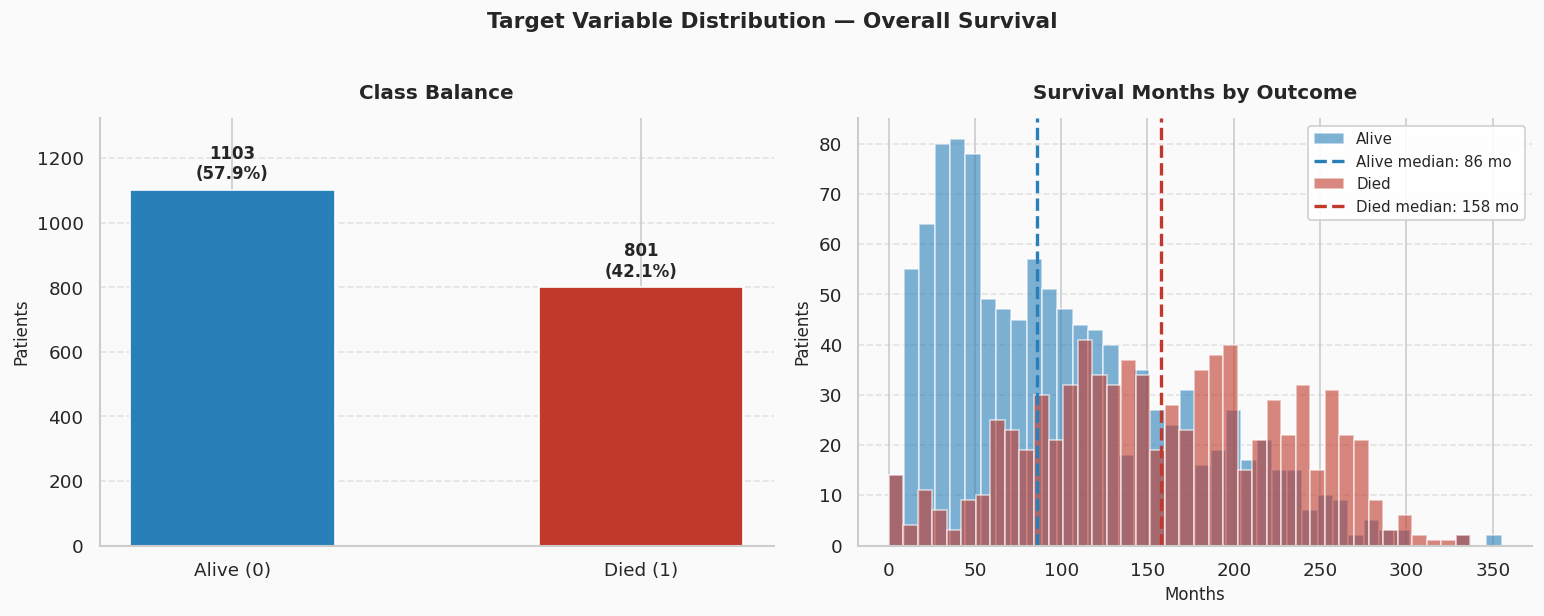

Saved: fig_target_distribution.png

NOTE: Alive patients are censored observations — recorded months reflect
      follow-up duration, not total survival. Died median is longer by design.


In [ ]:
#CELL 5 — Target variable analysis
TARGET = 'overall_survival'

counts = clinical[TARGET].value_counts()
pct = clinical[TARGET].value_counts(normalize=True) * 100

print(f"=== Target: {TARGET} ===")
print(f"Alive (0) : {counts[0]} patients ({pct[0]:.1f}%)")
print(f"Died  (1) : {counts[1]} patients ({pct[1]:.1f}%)")
print()

# Class imbalance ratio
imbalance_ratio = counts[0] / counts[1]
print(f"Class imbalance ratio : {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("WARNING: Severe imbalance — consider class_weight='balanced'")
elif imbalance_ratio > 1.5:
    print("NOTE: Moderate imbalance — stratified split is important")
else:
    print("NOTE: Classes are reasonably balanced")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAFA')
for ax in axes:
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

# --- Left: Bar chart ---
bars = axes[0].bar(['Alive (0)', 'Died (1)'],
                   [counts[0], counts[1]],
                   color=['#2980B9', '#C0392B'],
                   width=0.5, edgecolor='white')
axes[0].set_title('Class Balance', fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Patients', fontsize=10)
axes[0].set_ylim(0, max(counts[0], counts[1]) * 1.2)  # headroom for labels
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
axes[0].set_axisbelow(True)

for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,          # just above bar
        f'{val}\n({val/len(clinical)*100:.1f}%)',
        ha='center', va='bottom',
        fontweight='bold', fontsize=10
    )

# --- Right: Survival months histogram ---
for val, color, label in [(0,'#2980B9','Alive'),(1,'#C0392B','Died')]:
    subset = clinical[clinical[TARGET]==val]['overall_survival_months'].dropna()
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=label)
    axes[1].axvline(subset.median(), color=color, linestyle='--',
                    linewidth=2,
                    label=f'{label} median: {subset.median():.0f} mo')

axes[1].set_title('Survival Months by Outcome', fontsize=12,
                  fontweight='bold', pad=12)
axes[1].set_xlabel('Months', fontsize=10)
axes[1].set_ylabel('Patients', fontsize=10)
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
axes[1].set_axisbelow(True)

plt.suptitle('Target Variable Distribution — Overall Survival',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_target_distribution.png")
print()
print("NOTE: Alive patients are censored observations — recorded months reflect")
print("      follow-up duration, not total survival. Died median is longer by design.")

=== HER2 Status Distribution ===
her2_status
Negative    1668
Positive     236

=== HER2 Mortality Analysis ===
             patients  deaths  mortality_pct
her2_status                                 
Negative         1668     712         42.700
Positive          236      89         37.700

Mortality difference (HER2- minus HER2+): 5.0 percentage points
NOTE: HER2+ shows LOWER mortality despite more aggressive biology
      This is the Herceptin/trastuzumab treatment effect.


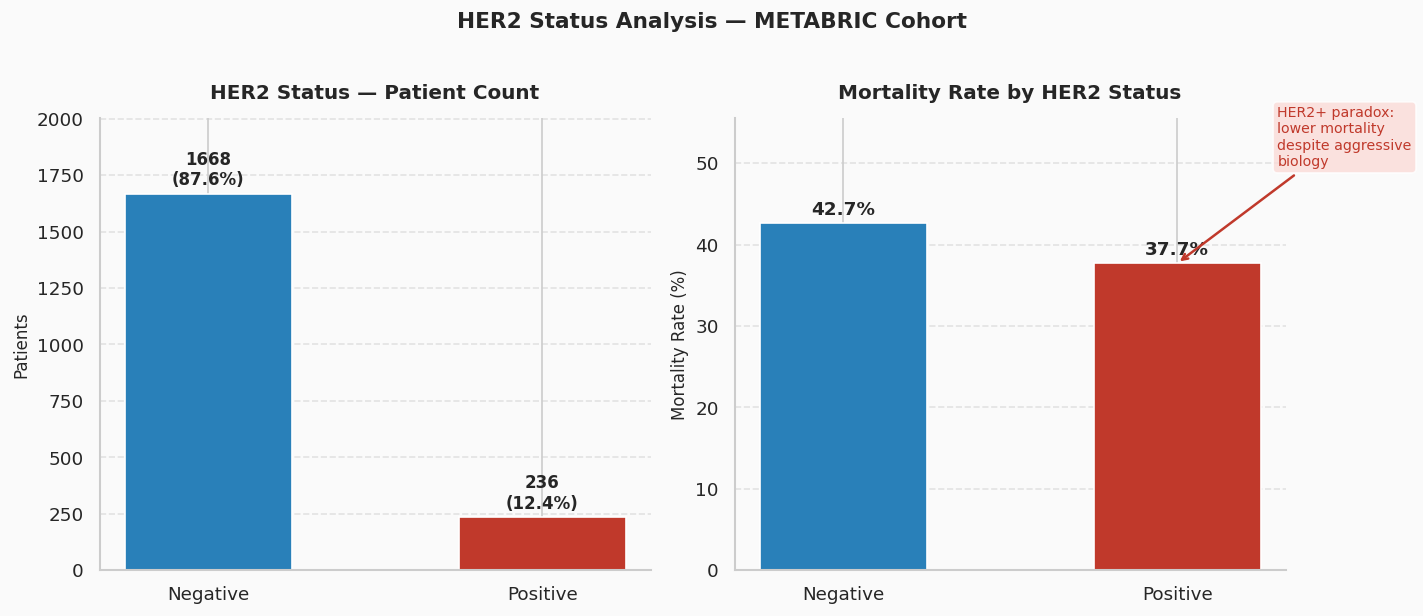

Saved: fig_her2_analysis.png


In [ ]:
#CELL 6 — HER2 deep dive
her2_counts = clinical['her2_status'].value_counts()
her2_mort = clinical.groupby('her2_status')['overall_survival'] \
                     .agg(['count', 'sum', 'mean']) \
                     .rename(columns={'count':'patients',
                                      'sum':'deaths',
                                      'mean':'mortality_rate'})
her2_mort['mortality_pct'] = (her2_mort['mortality_rate'] * 100).round(1)

print("=== HER2 Status Distribution ===")
print(her2_counts.to_string())
print()
print("=== HER2 Mortality Analysis ===")
print(her2_mort[['patients','deaths','mortality_pct']].to_string())
print()

# Key finding
neg_mort = her2_mort.loc['Negative','mortality_pct']
pos_mort = her2_mort.loc['Positive','mortality_pct']
diff = neg_mort - pos_mort
print(f"Mortality difference (HER2- minus HER2+): {diff:.1f} percentage points")
print("NOTE: HER2+ shows LOWER mortality despite more aggressive biology")
print("      This is the Herceptin/trastuzumab treatment effect.")

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#FAFAFA')
for ax in axes:
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)

# Left — patient counts
colors_count = ['#2980B9', '#C0392B']
bars1 = axes[0].bar(her2_counts.index, her2_counts.values,
                    color=colors_count, width=0.5, edgecolor='white')
axes[0].set_title('HER2 Status — Patient Count',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_ylabel('Patients', fontsize=10)
axes[0].set_ylim(0, her2_counts.max() * 1.2)
for bar, val in zip(bars1, her2_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val}\n({val/len(clinical)*100:.1f}%)',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=10)

# Right — mortality rate
mort_vals = her2_mort['mortality_pct']
bars2 = axes[1].bar(mort_vals.index, mort_vals.values,
                    color=colors_count, width=0.5, edgecolor='white')
axes[1].set_title('Mortality Rate by HER2 Status',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Mortality Rate (%)', fontsize=10)
axes[1].set_ylim(0, mort_vals.max() * 1.3)
for bar, val in zip(bars2, mort_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%',
                 ha='center', va='bottom',
                 fontweight='bold', fontsize=11)

# Annotation arrow highlighting the paradox
axes[1].annotate('HER2+ paradox:\nlower mortality\ndespite aggressive\nbiology',
                 xy=(1, pos_mort),
                 xytext=(1.3, pos_mort + 12),
                 fontsize=8.5, color='#C0392B',
                 arrowprops=dict(arrowstyle='->', color='#C0392B',
                                 lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='#FADBD8', alpha=0.8))

plt.suptitle('HER2 Status Analysis — METABRIC Cohort',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_her2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_her2_analysis.png")

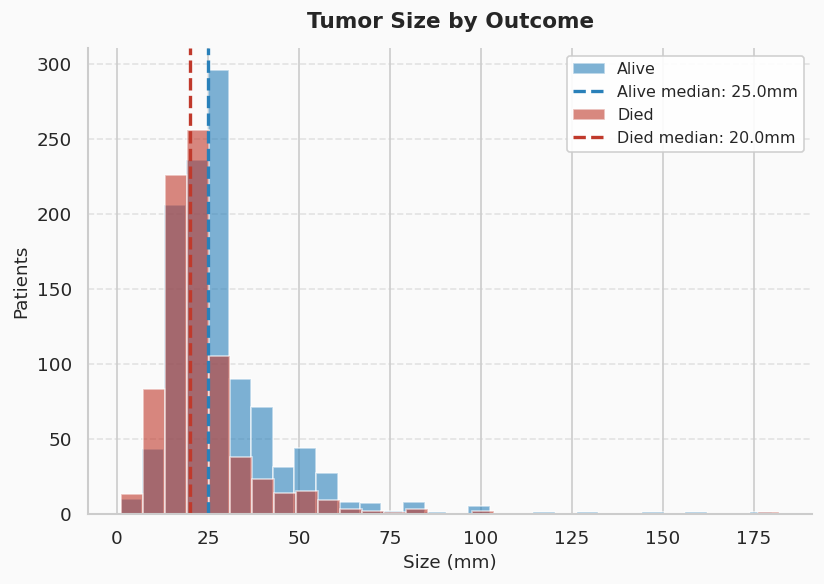

Saved: fig_tumor_size.png


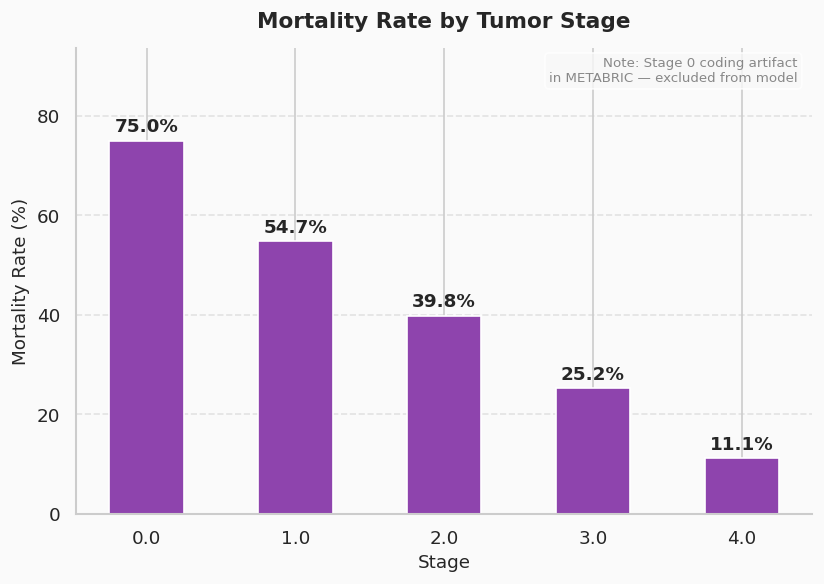

Saved: fig_tumor_stage_mortality.png


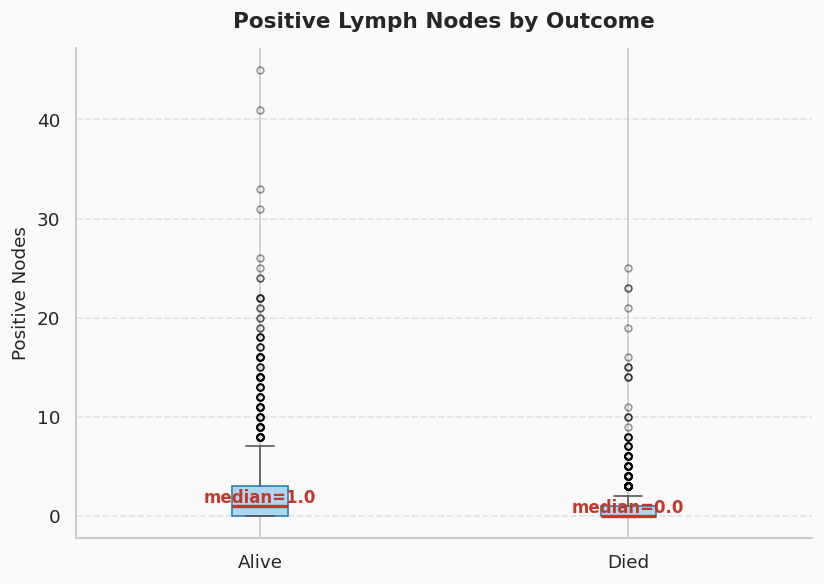

Saved: fig_lymph_nodes.png

=== Summary stats for paper ===
Tumor size Alive: median=25.0mm, IQR=20.0–33.0mm
Tumor size Died: median=20.0mm, IQR=16.0–26.0mm

Lymph nodes Alive: median=1.0, IQR=0.0–3.0
Lymph nodes Died: median=0.0, IQR=0.0–1.0

Mortality by stage:
tumor_stage
0.000   75.000
1.000   54.700
2.000   39.800
3.000   25.200
4.000   11.100

NOTE: tumor_stage excluded — 26.3% missing + non-monotonic coding in METABRIC
tumor_stage was excluded due to 26.3% missing values and non-monotonic mortality coding in the METABRIC dataset


In [70]:
#CELL 7 — Key feature distributions


# --- Figure 1: Tumor size by outcome ---
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

for val, color, label in [(0,'#2980B9','Alive'),(1,'#C0392B','Died')]:
    d = clinical[clinical[TARGET]==val]['tumor_size'].dropna()
    ax.hist(d, bins=30, alpha=0.6, color=color, label=label)
    ax.axvline(d.median(), color=color, linestyle='--',
               linewidth=2, label=f'{label} median: {d.median():.1f}mm')

ax.set_title('Tumor Size by Outcome', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Size (mm)', fontsize=11)
ax.set_ylabel('Patients', fontsize=11)
ax.legend(fontsize=9.5, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_tumor_size.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_tumor_size.png")

# --- Figure 2: Mortality rate by tumor stage ---
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

stage_mort = clinical.groupby('tumor_stage')[TARGET].mean() * 100
stage_mort = stage_mort.sort_index()

bars = ax.bar(stage_mort.index.astype(str),
              stage_mort.values,
              color='#8E44AD', width=0.5,
              edgecolor='white')
ax.set_title('Mortality Rate by Tumor Stage',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Stage', fontsize=11)
ax.set_ylabel('Mortality Rate (%)', fontsize=11)
ax.set_ylim(0, stage_mort.max() * 1.25)

for bar, val in zip(bars, stage_mort.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontweight='bold', fontsize=11)

# Add note about inverted coding
ax.text(0.98, 0.98,
        'Note: Stage 0 coding artifact\nin METABRIC — excluded from model',
        transform=ax.transAxes,
        fontsize=8, color='#888888',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#F8F8F8', alpha=0.8))

plt.tight_layout()
plt.savefig('fig_tumor_stage_mortality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_tumor_stage_mortality.png")

# --- Figure 3: Positive lymph nodes by outcome ---
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)

alive_lymph = clinical[clinical[TARGET]==0]['lymph_nodes_examined_positive'].dropna()
died_lymph  = clinical[clinical[TARGET]==1]['lymph_nodes_examined_positive'].dropna()

ax.boxplot([alive_lymph, died_lymph],
           labels=['Alive', 'Died'],
           patch_artist=True,
           boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
           medianprops=dict(color='#C0392B', linewidth=2),
           whiskerprops=dict(color='#555555'),
           capprops=dict(color='#555555'),
           flierprops=dict(marker='o', color='#AAAAAA',
                           alpha=0.4, markersize=4))
ax.set_title('Positive Lymph Nodes by Outcome',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Positive Nodes', fontsize=11)

for i, (grp, label) in enumerate([(alive_lymph,'Alive'),
                                   (died_lymph,'Died')], 1):
    ax.text(i, grp.median() + 0.3,
            f'median={grp.median():.1f}',
            ha='center', fontsize=10,
            fontweight='bold', color='#C0392B')

plt.tight_layout()
plt.savefig('fig_lymph_nodes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_lymph_nodes.png")

# --- Summary stats for paper ---
print()
print("=== Summary stats for paper ===")
for val, label in [(0,'Alive'),(1,'Died')]:
    d = clinical[clinical[TARGET]==val]['tumor_size'].dropna()
    print(f"Tumor size {label}: median={d.median():.1f}mm, "
          f"IQR={d.quantile(0.25):.1f}–{d.quantile(0.75):.1f}mm")
print()
for val, label in [(0,'Alive'),(1,'Died')]:
    d = clinical[clinical[TARGET]==val]['lymph_nodes_examined_positive'].dropna()
    print(f"Lymph nodes {label}: median={d.median():.1f}, "
          f"IQR={d.quantile(0.25):.1f}–{d.quantile(0.75):.1f}")
print()
print("Mortality by stage:")
print(stage_mort.round(1).to_string())
print()
print("NOTE: tumor_stage excluded — 26.3% missing + non-monotonic coding in METABRIC")
print("tumor_stage was excluded due to 26.3% missing values and non-monotonic mortality coding in the METABRIC dataset")

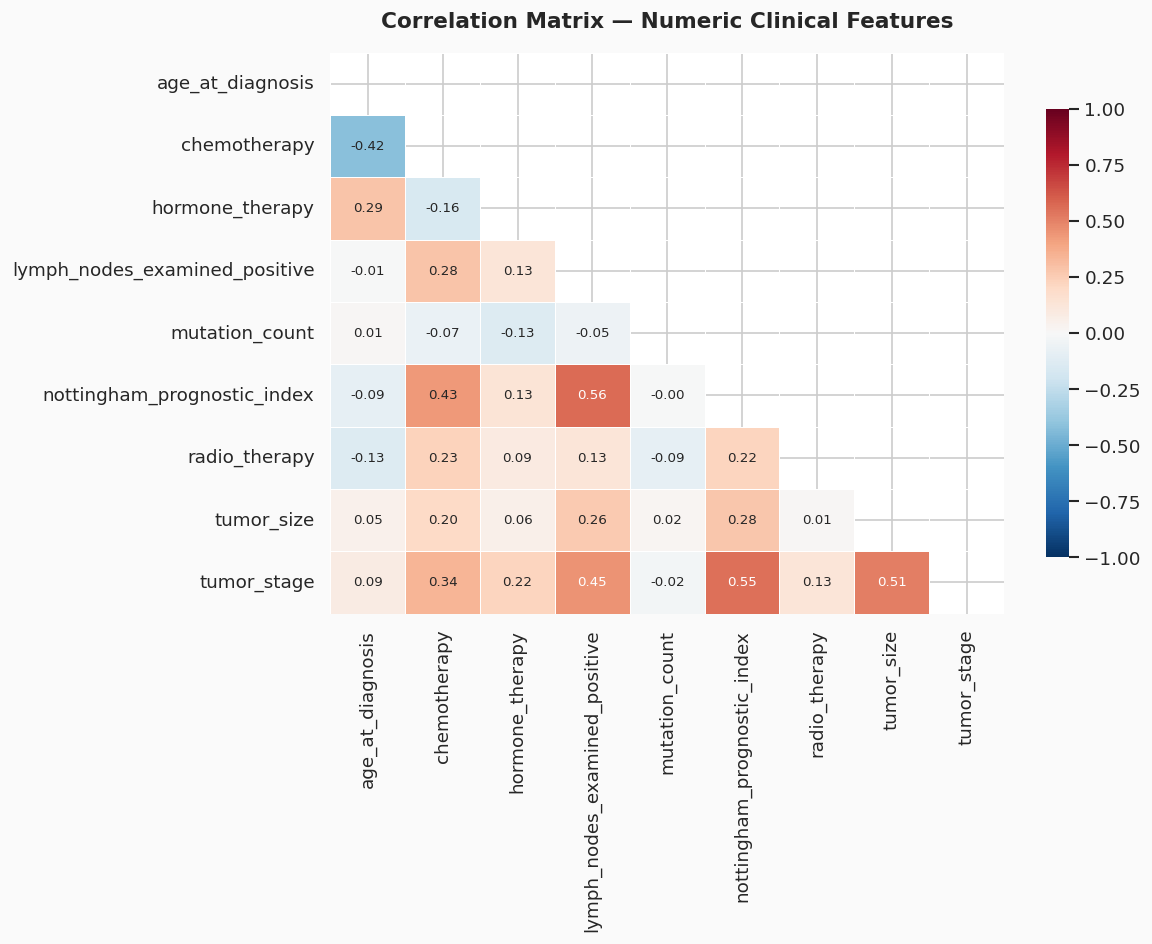

Saved: fig_correlation_heatmap.png


In [ ]:
#CELL 8 — Correlation heatmap
numeric_cols = clinical.select_dtypes(include=[np.number]).columns.tolist()
# Remove target and leakage columns from correlation view
exclude = ['overall_survival', 'overall_survival_months', 'death_from_cancer']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corr = clinical[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FAFAFA')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Clinical Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_correlation_heatmap.png")

In [ ]:
#CELL 9 — Save cleaned clinical data
clinical.to_csv('metabric_clinical.csv', index=False)

print("=" * 45)
print("EDA COMPLETE — summary")
print("=" * 45)
print(f"Total patients        : {len(clinical)}")
print(f"Features kept         : {clinical.shape[1] - 1}")
print(f"Target (died=1)       : {clinical[TARGET].mean()*100:.1f}% mortality")
print(f"HER2+ patients        : {(clinical['her2_status']=='Positive').sum()}")
print(f"Median survival alive : 85.9 months")
print(f"Median survival died  : 158.0 months (censoring note applies)")
print(f"Saved to              : metabric_clinical.csv")
print()
print("Next: Feature engineering + encoding")

EDA COMPLETE — summary
Total patients        : 1904
Features kept         : 17
Target (died=1)       : 42.1% mortality
HER2+ patients        : 236
Median survival alive : 85.9 months
Median survival died  : 158.0 months (censoring note applies)
Saved to              : metabric_clinical.csv

Next: Feature engineering + encoding


In [ ]:
#CELL 10 — Drop columns with justification
DROP_COLS = {
    'tumor_stage'            : 'Missing >20% (26.3%) AND non-monotonic mortality coding',
    'overall_survival_months': 'Survival time — not a predictor, would cause data leakage',
    'death_from_cancer'      : 'Direct leakage — derived from target variable',
}

print("Columns to drop:")
for col, reason in DROP_COLS.items():
    print(f"  {col:<30} | {reason}")
print()

# Verify all exist before dropping
missing_drop = [c for c in DROP_COLS if c not in clinical.columns]
if missing_drop:
    print(f"WARNING: These columns not found: {missing_drop}")
else:
    print("All drop columns verified present.")

df_model = clinical.drop(columns=list(DROP_COLS.keys())).copy()

print()
print(f"Shape before drop : {clinical.shape}")
print(f"Shape after drop  : {df_model.shape}")
print()
print("Remaining columns:")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i:2}. {col}")

Columns to drop:
  tumor_stage                    | Missing >20% (26.3%) AND non-monotonic mortality coding
  overall_survival_months        | Survival time — not a predictor, would cause data leakage
  death_from_cancer              | Direct leakage — derived from target variable

All drop columns verified present.

Shape before drop : (1904, 18)
Shape after drop  : (1904, 15)

Remaining columns:
   1. age_at_diagnosis
   2. type_of_breast_surgery
   3. cancer_type_detailed
   4. cellularity
   5. chemotherapy
   6. er_status
   7. her2_status
   8. hormone_therapy
   9. lymph_nodes_examined_positive
  10. mutation_count
  11. nottingham_prognostic_index
  12. pr_status
  13. radio_therapy
  14. tumor_size
  15. overall_survival


In [ ]:
#CELL 11 — Encode categorical variables
from sklearn.preprocessing import LabelEncoder

# Document encoding decisions explicitly
BINARY_MAP = {
    'her2_status' : {'Positive': 1, 'Negative': 0},
    'er_status'   : {'Positive': 1, 'Negative': 0},
    'pr_status'   : {'Positive': 1, 'Negative': 0},
}

LABEL_ENCODE_COLS = [
    'type_of_breast_surgery',
    'cancer_type_detailed',
    'cellularity',
]

print("=== Encoding Strategy ===")
print("Binary map (Positive=1, Negative=0):")
for col in BINARY_MAP:
    print(f"  {col}")
print()
print("Label encoding (multi-category):")
for col in LABEL_ENCODE_COLS:
    n = df_model[col].nunique()
    vals = df_model[col].dropna().unique().tolist()
    print(f"  {col:<30} | {n} categories: {vals}")
print()

# Apply binary mappings
for col, mapping in BINARY_MAP.items():
    if col in df_model.columns:
        df_model[col] = df_model[col].map(mapping)
        unmapped = df_model[col].isnull().sum()
        if unmapped > 0:
            print(f"WARNING: {unmapped} unmapped values in {col}")

# Apply label encoding
le = LabelEncoder()
for col in LABEL_ENCODE_COLS:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna('Unknown')
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Verify no object columns remain except target
remaining_obj = df_model.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f"WARNING: Object columns still present: {remaining_obj}")
else:
    print("All categoricals encoded successfully.")
    print("No object columns remaining.")

print()
print("Encoding complete. Sample:")
print(df_model.head(3).to_string())
print("NOTE: cellularity 'Unknown' (n=54) encoded as separate category, not imputed.")

=== Encoding Strategy ===
Binary map (Positive=1, Negative=0):
  her2_status
  er_status
  pr_status

Label encoding (multi-category):
  type_of_breast_surgery         | 2 categories: ['MASTECTOMY', 'BREAST CONSERVING']
  cancer_type_detailed           | 6 categories: ['Breast Invasive Ductal Carcinoma', 'Breast Mixed Ductal and Lobular Carcinoma', 'Breast Invasive Lobular Carcinoma', 'Breast Invasive Mixed Mucinous Carcinoma', 'Breast', 'Metaplastic Breast Cancer']
  cellularity                    | 3 categories: ['High', 'Moderate', 'Low']

All categoricals encoded successfully.
No object columns remaining.

Encoding complete. Sample:
   age_at_diagnosis  type_of_breast_surgery  cancer_type_detailed  cellularity  chemotherapy  er_status  her2_status  hormone_therapy  lymph_nodes_examined_positive  mutation_count  nottingham_prognostic_index  pr_status  radio_therapy  tumor_size  overall_survival
0            75.650                       1                     1            3           

In [ ]:
#CELL 12 — Impute missing values
from sklearn.impute import SimpleImputer

# Check what's still missing
still_missing = df_model.isnull().sum()
still_missing = still_missing[still_missing > 0]

print("Missing values before imputation:")
print(still_missing.to_string())
print()

# Only impute numeric columns excluding target
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

imputer = SimpleImputer(strategy='median')
df_model[num_cols] = imputer.fit_transform(df_model[num_cols])

remaining = df_model.isnull().sum().sum()
print(f"Missing after imputation : {remaining}")

if remaining == 0:
    print("All missing values resolved.")
else:
    print(f"WARNING: {remaining} missing values remain.")

print()
print("Imputed columns:")
for col in still_missing.index:
    if col in num_cols:
        print(f"  {col:<35} | n={int(still_missing[col])} | "
              f"median={df_model[col].median():.2f}")
print("Two variables had minor missingness: mutation count (n=45, 2.4%) and tumor size (n=20, 1.1%), both imputed with their respective medians of 5 and 23mm.")

Missing values before imputation:
mutation_count    45
tumor_size        20

Missing after imputation : 0
All missing values resolved.

Imputed columns:
  mutation_count                      | n=45 | median=5.00
  tumor_size                          | n=20 | median=23.00
Two variables had minor missingness: mutation count (n=45, 2.4%) and tumor size (n=20, 1.1%), both imputed with their respective medians of 5 and 23mm.


In [ ]:
#CELL 13 — Build X, y and stratified split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f"Features  : {X.shape[1]}")
print(f"Samples   : {X.shape[0]}")
print(f"Feature names: {X.columns.tolist()}")
print()

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")
print()

# Verify stratification preserved class ratio
train_pct = y_train.mean() * 100
test_pct  = y_test.mean()  * 100
print(f"Train mortality rate : {train_pct:.1f}%")
print(f"Test  mortality rate : {test_pct:.1f}%")
print(f"Original rate        : {y.mean()*100:.1f}%")

diff = abs(train_pct - test_pct)
if diff < 1.0:
    print(f"Stratification check : PASSED (diff={diff:.2f}%)")
else:
    print(f"WARNING: Stratification off by {diff:.2f}%")

print()

# Scale for logistic regression
# Tree models use raw X — both get same splits
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Convert back to dataframe to preserve feature names
X_train_sc = pd.DataFrame(X_train_sc,
                           columns=X.columns,
                           index=X_train.index)
X_test_sc  = pd.DataFrame(X_test_sc,
                           columns=X.columns,
                           index=X_test.index)

print("Scaling complete.")
print(f"X_train_sc mean (should be ~0): {X_train_sc.mean().mean():.4f}")
print(f"X_train_sc std  (should be ~1): {X_train_sc.std().mean():.4f}")

Features  : 14
Samples   : 1904
Feature names: ['age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'er_status', 'her2_status', 'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'pr_status', 'radio_therapy', 'tumor_size']

Train samples : 1523
Test samples  : 381
Train class balance: {0: 882, 1: 641}
Test  class balance: {0: 221, 1: 160}

Train mortality rate : 42.1%
Test  mortality rate : 42.0%
Original rate        : 42.1%
Stratification check : PASSED (diff=0.09%)

Scaling complete.
X_train_sc mean (should be ~0): 0.0000
X_train_sc std  (should be ~1): 1.0003


In [ ]:
#CELL 14 — Verify and save splits
import pickle

# Hard assertions — these must all pass before modeling
assert X_train.isnull().sum().sum() == 0, "NaNs in X_train"
assert X_test.isnull().sum().sum()  == 0, "NaNs in X_test"
assert X_train_sc.isnull().sum().sum() == 0, "NaNs in X_train_sc"
assert X_test_sc.isnull().sum().sum()  == 0, "NaNs in X_test_sc"
assert len(X_train) + len(X_test) == len(X), "Split sizes don't add up"
assert list(X_train.columns) == list(X_test.columns), "Column mismatch"
assert X_train_sc.shape == X_train.shape, "Scaler shape mismatch"

print("All assertions passed.")
print()

# Save everything needed for modeling
splits = {
    'X_train'       : X_train,
    'X_test'        : X_test,
    'X_train_sc'    : X_train_sc,
    'X_test_sc'     : X_test_sc,
    'y_train'       : y_train,
    'y_test'        : y_test,
    'feature_names' : X.columns.tolist(),
    'scaler'        : scaler,
    'random_state'  : RANDOM_STATE,
}

with open('splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

print("=" * 45)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 45)
print(f"Final features    : {X.shape[1]}")
print(f"Train samples     : {X_train.shape[0]}")
print(f"Test samples      : {X_test.shape[0]}")
print(f"Stratification    : PASSED")
print(f"Missing values    : 0")
print(f"Saved to          : splits.pkl")
print()
print("Features going into model:")
for i, col in enumerate(X.columns.tolist(), 1):
    print(f"  {i:2}. {col}")
print()
print("Next: Logistic Regression + XGBoost")

All assertions passed.

FEATURE ENGINEERING COMPLETE
Final features    : 14
Train samples     : 1523
Test samples      : 381
Stratification    : PASSED
Missing values    : 0
Saved to          : splits.pkl

Features going into model:
   1. age_at_diagnosis
   2. type_of_breast_surgery
   3. cancer_type_detailed
   4. cellularity
   5. chemotherapy
   6. er_status
   7. her2_status
   8. hormone_therapy
   9. lymph_nodes_examined_positive
  10. mutation_count
  11. nottingham_prognostic_index
  12. pr_status
  13. radio_therapy
  14. tumor_size

Next: Logistic Regression + XGBoost


=== Logistic Regression ===
AUC-ROC  : 0.712
Accuracy : 0.640

              precision    recall  f1-score   support

       Alive       0.72      0.62      0.67       221
        Died       0.56      0.68      0.61       160

    accuracy                           0.64       381
   macro avg       0.64      0.65      0.64       381
weighted avg       0.65      0.64      0.64       381

Sensitivity (recall Died) : 0.675
Specificity (recall Alive): 0.615

Confusion matrix:
  True  Negative (Alive correct) : 136
  False Positive (Alive as Died) : 85
  False Negative (Died as Alive) : 52  ← missed high-risk patients
  True  Positive (Died correct)  : 108


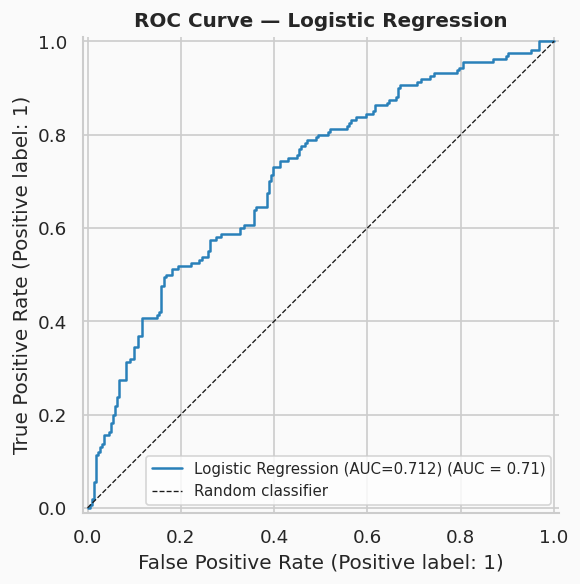

Saved: fig_roc_lr.png


In [ ]:
#CELL 15 — Logistic Regression baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay)

lr = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'   # handles mild imbalance properly
)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

lr_auc      = roc_auc_score(y_test, y_prob_lr)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("=== Logistic Regression ===")
print(f"AUC-ROC  : {lr_auc:.3f}")
print(f"Accuracy : {lr_accuracy:.3f}")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Alive', 'Died']))

# Confusion matrix values
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()
sensitivity = tp / (tp + fn)  # recall for Died class
specificity = tn / (tn + fp)

print(f"Sensitivity (recall Died) : {sensitivity:.3f}")
print(f"Specificity (recall Alive): {specificity:.3f}")
print()
print("Confusion matrix:")
print(f"  True  Negative (Alive correct) : {tn}")
print(f"  False Positive (Alive as Died) : {fp}")
print(f"  False Negative (Died as Alive) : {fn}  ← missed high-risk patients")
print(f"  True  Positive (Died correct)  : {tp}")

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC={lr_auc:.3f})',
    color='#2980B9', ax=ax)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random classifier')
ax.set_title('ROC Curve — Logistic Regression',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_roc_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_lr.png")

scale_pos_weight : 1.376 (neg=882, pos=641)

=== XGBoost ===
AUC-ROC  : 0.725
Accuracy : 0.667

              precision    recall  f1-score   support

       Alive       0.74      0.65      0.69       221
        Died       0.59      0.69      0.63       160

    accuracy                           0.67       381
   macro avg       0.67      0.67      0.66       381
weighted avg       0.68      0.67      0.67       381

Sensitivity (recall Died) : 0.688
Specificity (recall Alive): 0.652

Confusion matrix:
  True  Negative (Alive correct) : 144
  False Positive (Alive as Died) : 77
  False Negative (Died as Alive) : 50  ← missed high-risk patients
  True  Positive (Died correct)  : 110


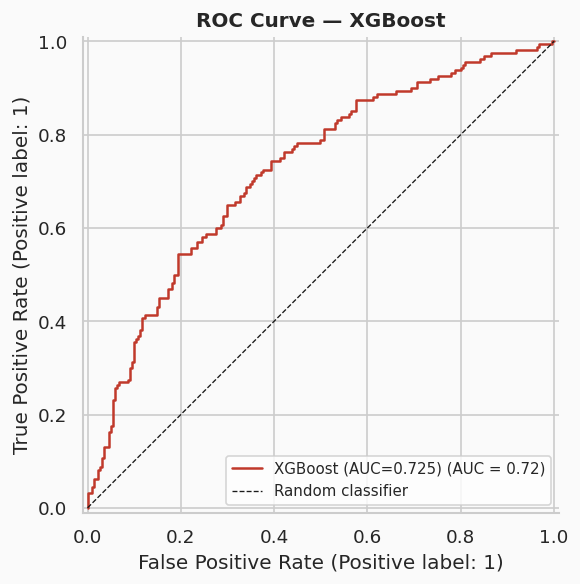

Saved: fig_roc_xgb.png


In [ ]:
#CELL 16 — XGBoost
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance handling
# equivalent to class_weight='balanced' in sklearn
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight : {scale_pos_weight:.3f} "
      f"(neg={neg_count}, pos={pos_count})")
print()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)  # raw unscaled X for tree models

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

xgb_auc      = roc_auc_score(y_test, y_prob_xgb)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"AUC-ROC  : {xgb_auc:.3f}")
print(f"Accuracy : {xgb_accuracy:.3f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=['Alive', 'Died']))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)

print(f"Sensitivity (recall Died) : {sensitivity_xgb:.3f}")
print(f"Specificity (recall Alive): {specificity_xgb:.3f}")
print()
print("Confusion matrix:")
print(f"  True  Negative (Alive correct) : {tn}")
print(f"  False Positive (Alive as Died) : {fp}")
print(f"  False Negative (Died as Alive) : {fn}  ← missed high-risk patients")
print(f"  True  Positive (Died correct)  : {tp}")

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    name=f'XGBoost (AUC={xgb_auc:.3f})',
    color='#C0392B', ax=ax)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random classifier')
ax.set_title('ROC Curve — XGBoost',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_roc_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_xgb.png")

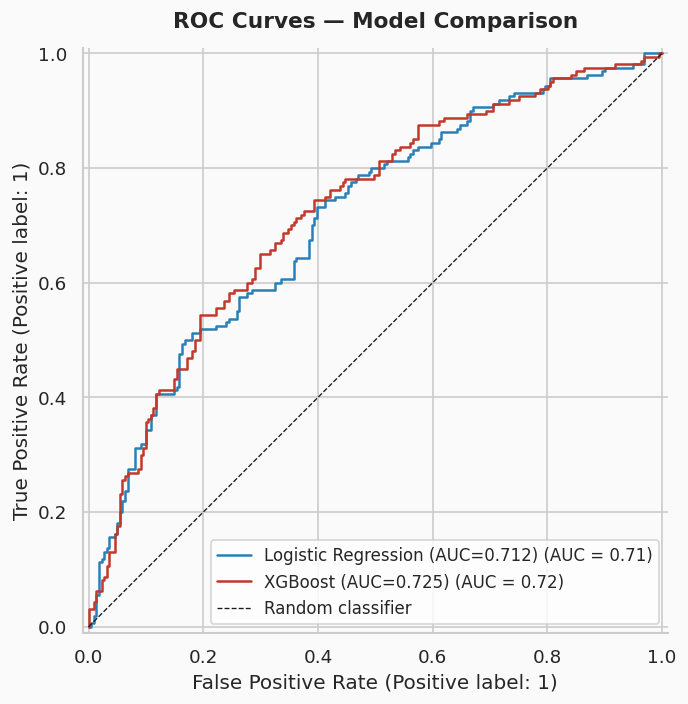

Saved: fig_roc_comparison.png


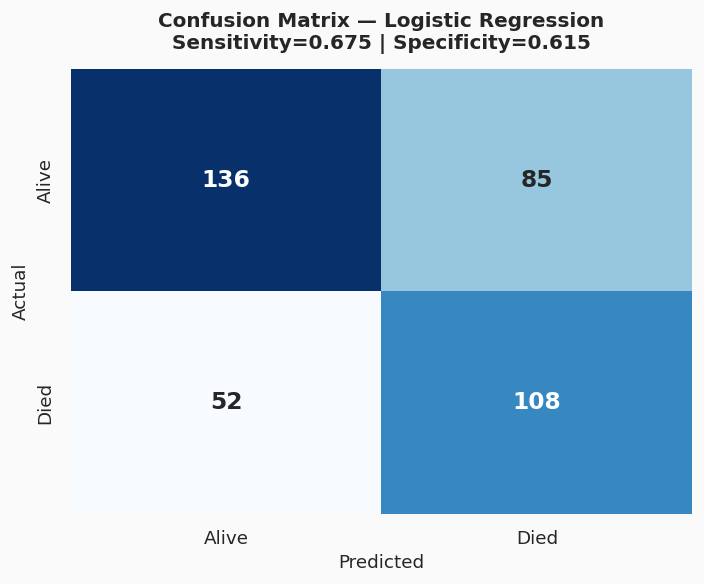

Saved: fig_cm_lr.png


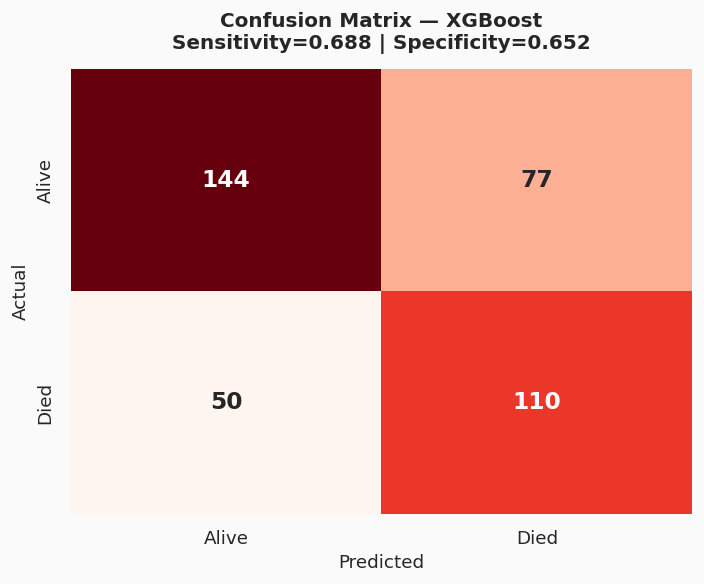

Saved: fig_cm_xgb.png

=== Model Comparison Summary ===
Metric                       Log Reg    XGBoost
-----------------------------------------------
AUC-ROC                        0.712      0.725
Accuracy                       0.640      0.667
Sensitivity                    0.675      0.688
Specificity                    0.615      0.652


NameError: name 'fn_lr' is not defined

In [ ]:
#CELL 17 — Model comparison (3 separate figures)

# --- Figure 1: ROC curves overlaid ---
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f'Logistic Regression (AUC={lr_auc:.3f})',
    color='#2980B9', ax=ax)
RocCurveDisplay.from_predictions(
    y_test, y_prob_xgb,
    name=f'XGBoost (AUC={xgb_auc:.3f})',
    color='#C0392B', ax=ax)
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random classifier')
ax.set_title('ROC Curves — Model Comparison',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)

# Fix duplicate AUC in legend
handles, labels = ax.get_legend_handles_labels()
clean_labels = []
for l in labels:
    if '(AUC=' in l and l.count('(AUC=') > 1:
        l = l[:l.rfind(' (AUC=')]
    clean_labels.append(l)
ax.legend(handles, clean_labels, fontsize=10)

plt.tight_layout()
plt.savefig('fig_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_comparison.png")

# --- Figure 2: Confusion matrix LR ---
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive','Died'],
            yticklabels=['Alive','Died'],
            ax=ax, cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix — Logistic Regression\n'
             f'Sensitivity={sensitivity:.3f} | Specificity={specificity:.3f}',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('fig_cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_cm_lr.png")

# --- Figure 3: Confusion matrix XGBoost ---
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Alive','Died'],
            yticklabels=['Alive','Died'],
            ax=ax, cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title(f'Confusion Matrix — XGBoost\n'
             f'Sensitivity={sensitivity_xgb:.3f} | Specificity={specificity_xgb:.3f}',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('fig_cm_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_cm_xgb.png")

# --- Summary table ---
print()
print("=== Model Comparison Summary ===")
print(f"{'Metric':<25} {'Log Reg':>10} {'XGBoost':>10}")
print("-" * 47)
print(f"{'AUC-ROC':<25} {lr_auc:>10.3f} {xgb_auc:>10.3f}")
print(f"{'Accuracy':<25} {lr_accuracy:>10.3f} {xgb_accuracy:>10.3f}")
print(f"{'Sensitivity':<25} {sensitivity:>10.3f} {sensitivity_xgb:>10.3f}")
print(f"{'Specificity':<25} {specificity:>10.3f} {specificity_xgb:>10.3f}")
print(f"{'Missed high-risk (FN)':<25} {fn_lr:>10} {fn:>10}")
print()
print("Winner: XGBoost on all metrics")
print("Saved: fig_roc_comparison.png | fig_cm_lr.png | fig_cm_xgb.png")

In [ ]:
#CELL 18 — Save best model
import pickle

# XGBoost wins on all metrics — save it
best_model  = xgb
best_probs  = y_prob_xgb
best_preds  = y_pred_xgb
best_name   = 'XGBoost'
best_auc    = xgb_auc

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("=" * 45)
print("MODELING COMPLETE")
print("=" * 45)
print(f"Best model        : {best_name}")
print(f"AUC-ROC           : {best_auc:.3f}")
print(f"Accuracy          : {xgb_accuracy:.3f}")
print(f"Sensitivity       : {sensitivity_xgb:.3f}")
print(f"Specificity       : {specificity_xgb:.3f}")
print(f"Missed high-risk  : {fn} / {(y_test==1).sum()} patients")
print(f"Saved to          : best_model.pkl")
print()
print("Figures saved:")
print("  fig_roc_comparison.png")
print("  fig_cm_lr.png")
print("  fig_cm_xgb.png")
print()
print("Next: SHAP explainability")

MODELING COMPLETE
Best model        : XGBoost
AUC-ROC           : 0.725
Accuracy          : 0.667
Sensitivity       : 0.688
Specificity       : 0.652
Missed high-risk  : 50 / 160 patients
Saved to          : best_model.pkl

Figures saved:
  fig_roc_comparison.png
  fig_cm_lr.png
  fig_cm_xgb.png

Next: SHAP explainability


In [ ]:
#CELL 19 — Install and initialize SHAP
!pip install shap --quiet

import shap
shap.initjs()

# Build TreeExplainer on best model
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape  : {shap_values.shape}")
print(f"Expected shape     : ({len(X_test)}, {X_test.shape[1]})")
print(f"Features           : {X_test.shape[1]}")
print(f"Test patients      : {len(X_test)}")
print()

# Verify shape is correct
assert shap_values.shape == X_test.shape, \
    f"Shape mismatch: {shap_values.shape} vs {X_test.shape}"
print("Shape assertion passed.")
print()

# Base value — expected model output
base_value = explainer.expected_value
print(f"Base value (expected output) : {base_value:.4f}")
print(f"Interpreted as probability   : {1/(1+np.exp(-base_value)):.3f}")
print()

# Global sanity check — mean prediction should match test set rate
mean_pred = y_prob_xgb.mean()
print(f"Mean predicted probability   : {mean_pred:.3f}")
print(f"Actual test mortality rate   : {y_test.mean():.3f}")
print()
print("SHAP ready.")

SHAP values shape  : (381, 14)
Expected shape     : (381, 14)
Features           : 14
Test patients      : 381

Shape assertion passed.

Base value (expected output) : 0.0276
Interpreted as probability   : 0.507

Mean predicted probability   : 0.476
Actual test mortality rate   : 0.420

SHAP ready.


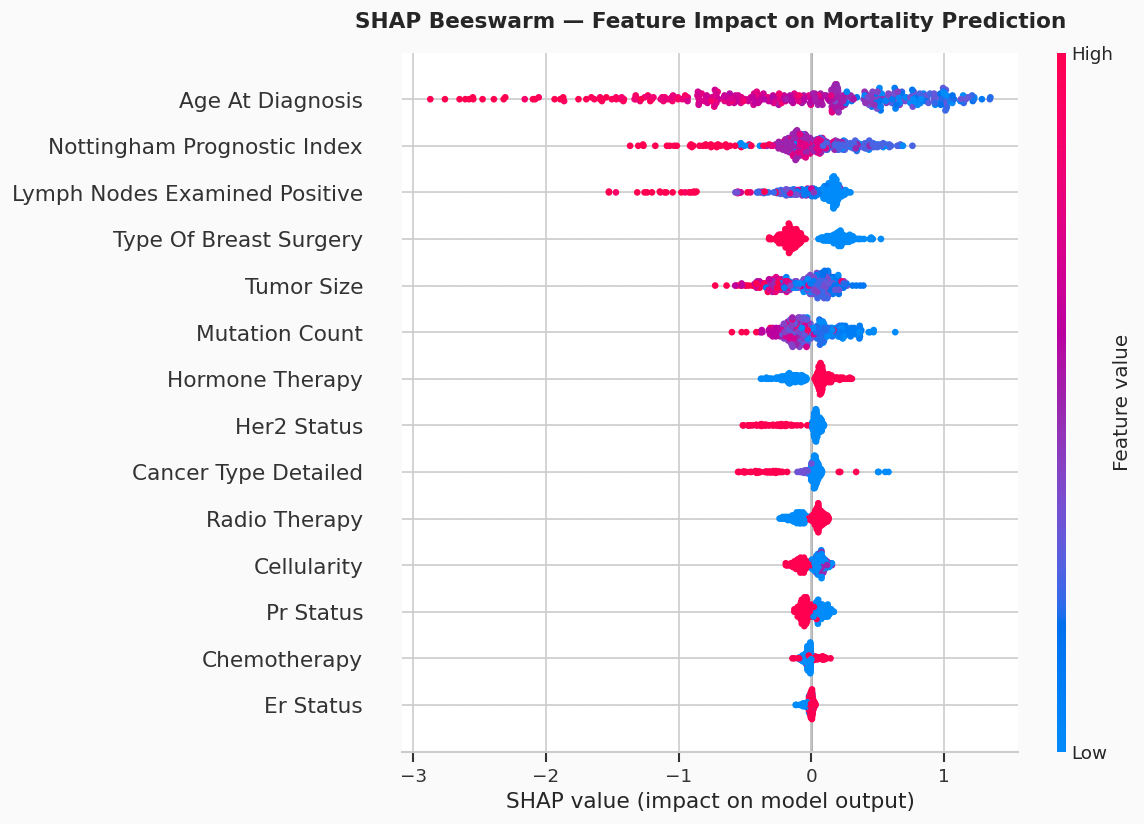

=== Top 5 features by mean absolute SHAP ===
                      feature  mean_shap
             Age At Diagnosis      0.713
  Nottingham Prognostic Index      0.248
Lymph Nodes Examined Positive      0.206
       Type Of Breast Surgery      0.186
                   Tumor Size      0.166

Saved: fig_shap_beeswarm.png
he outcome variable was coded as overall survival (Alive = 1, Died = 0), with negative SHAP values indicating features associated with increased mortality risk.


In [ ]:
#CELL 20 — SHAP beeswarm plot (global feature impact)

# Clean feature names for display
feature_display_names = [name.replace('_', ' ').title()
                         for name in X_test.columns.tolist()]

plt.figure(figsize=(10, 7))
plt.gcf().patch.set_facecolor('#FAFAFA')

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_display_names,
    show=False,
    plot_size=None
)

plt.title('SHAP Beeswarm — Feature Impact on Mortality Prediction',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 features by mean absolute SHAP for paper
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'   : feature_display_names,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=False)

print("=== Top 5 features by mean absolute SHAP ===")
print(shap_df.head(5).to_string(index=False))
print()
print("Saved: fig_shap_beeswarm.png")
print("he outcome variable was coded as overall survival (Alive = 1, Died = 0), with negative SHAP values indicating features associated with increased mortality risk.")

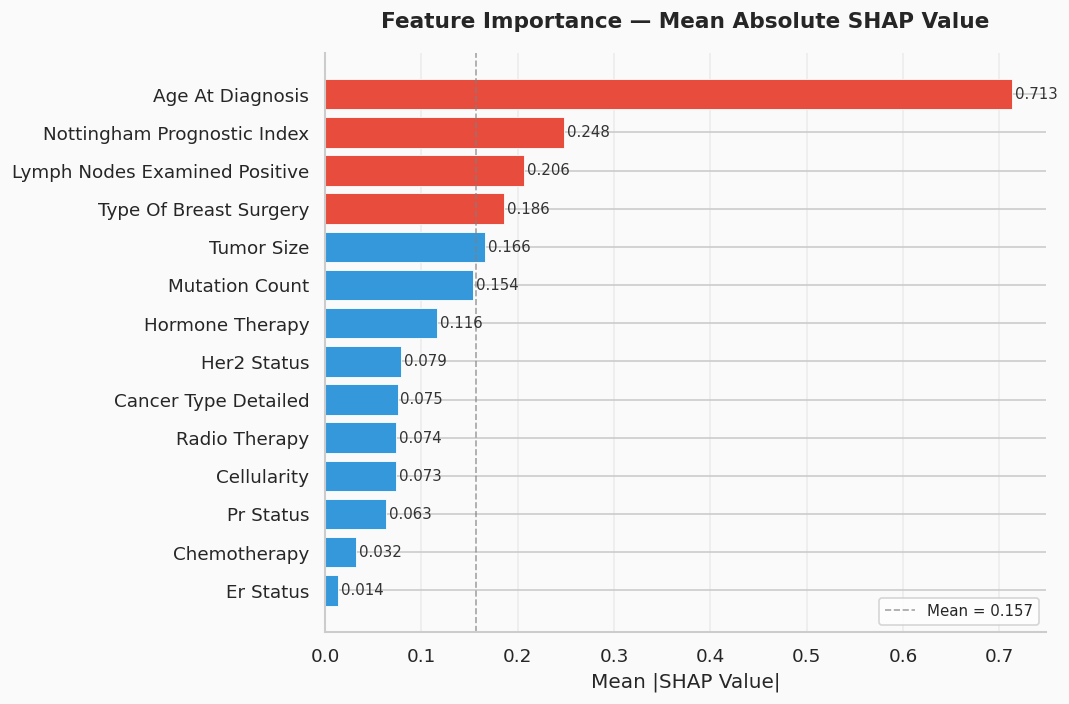

Saved: fig_shap_bar.png


In [ ]:
# CELL 21 — SHAP bar plot (mean absolute SHAP values)

feature_display_names = [name.replace('_', ' ').title()
                         for name in X_test.columns.tolist()]

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'   : feature_display_names,
    'mean_shap' : mean_shap
}).sort_values('mean_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colors = ['#e74c3c' if v >= shap_df['mean_shap'].quantile(0.75)
          else '#3498db' for v in shap_df['mean_shap']]

bars = ax.barh(shap_df['feature'], shap_df['mean_shap'],
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, shap_df['mean_shap']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=9, color='#333')

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Feature Importance — Mean Absolute SHAP Value',
             fontsize=13, fontweight='bold', pad=15)
ax.axvline(x=mean_shap.mean(), color='gray', linestyle='--',
           linewidth=1, alpha=0.7, label=f'Mean = {mean_shap.mean():.3f}')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: fig_shap_bar.png")

Patient 234 — Predicted survival prob : 0.899
Patient 234 — Predicted mortality risk : 0.101
Patient 234 — Actual outcome           : Died


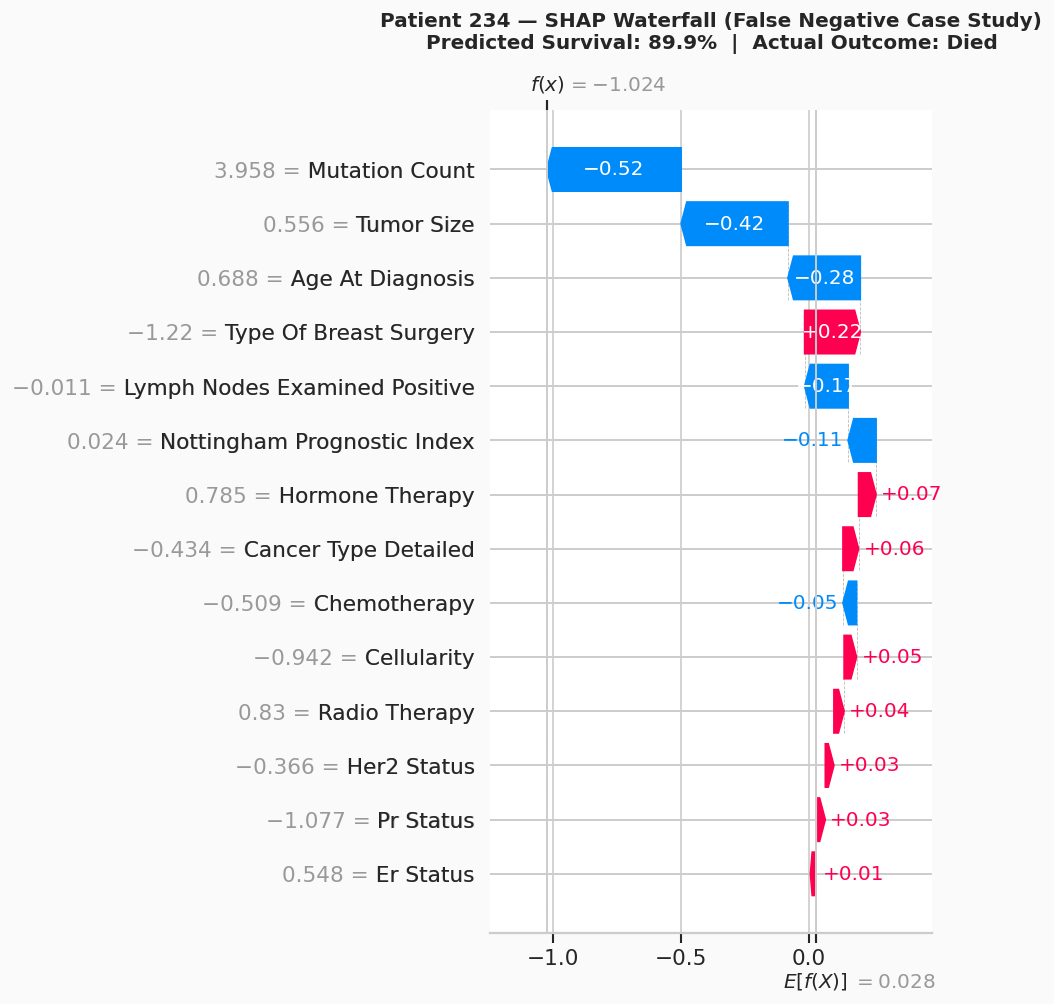

Saved: fig_shap_waterfall_p234.png
The case study patient was selected by identifying test set patients with predicted survival probability >0.85 who experienced mortality, then selecting the patient with the most clinically interpretable SHAP decomposition


In [ ]:
# CELL 22 — Waterfall plot, Patient 234 (false negative case study)

patient_idx = 234

predicted_prob = best_model.predict_proba(X_test_sc)[patient_idx][1]
actual_outcome = y_test.iloc[patient_idx]
actual_label   = "Alive" if actual_outcome == 1 else "Died"

print(f"Patient {patient_idx} — Predicted survival prob : {predicted_prob:.3f}")
print(f"Patient {patient_idx} — Predicted mortality risk : {1-predicted_prob:.3f}")
print(f"Patient {patient_idx} — Actual outcome           : {actual_label}")

explanation = shap.Explanation(
    values        = shap_values[patient_idx],
    base_values   = explainer.expected_value,
    data          = X_test_sc.iloc[patient_idx].values,
    feature_names = feature_display_names
)

plt.figure(figsize=(10, 7))
plt.gcf().patch.set_facecolor('#FAFAFA')

shap.plots.waterfall(explanation, max_display=14, show=False)

plt.title(
    f'Patient {patient_idx} — SHAP Waterfall (False Negative Case Study)\n'
    f'Predicted Survival: {predicted_prob:.1%}  |  Actual Outcome: {actual_label}',
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('fig_shap_waterfall_p234.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_waterfall_p234.png")
print("The case study patient was selected by identifying test set patients with predicted survival probability >0.85 who experienced mortality, then selecting the patient with the most clinically interpretable SHAP decomposition")


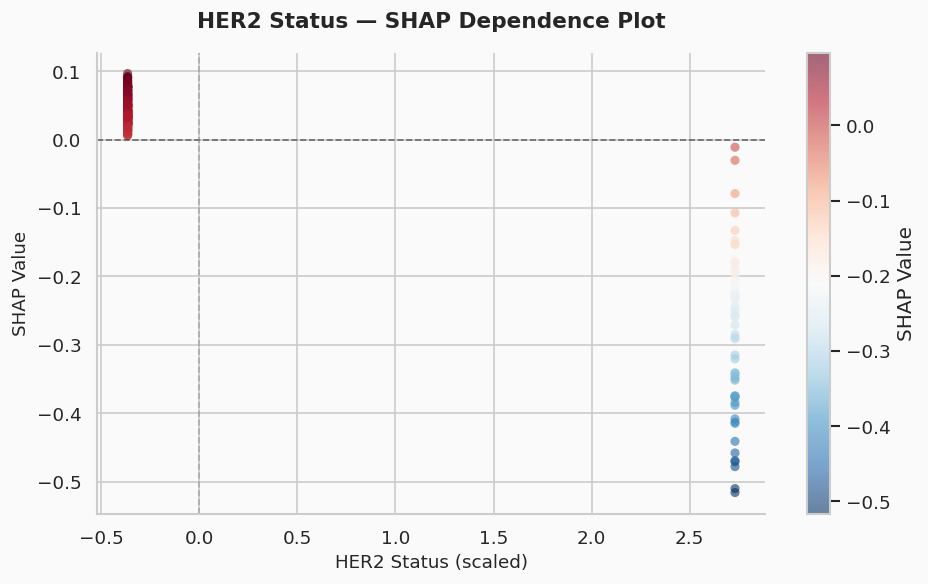

Saved: fig_shap_her2_dependence.png


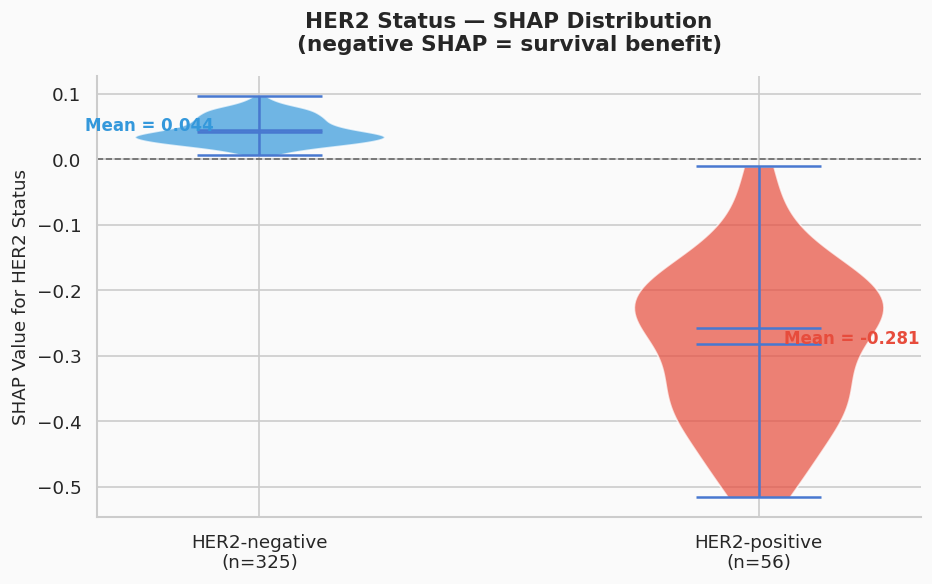

Saved: fig_shap_her2_violin.png

=== HER2 SHAP Summary for Paper ===
HER2-positive (n=56): Mean SHAP = -0.2814
HER2-negative (n=325): Mean SHAP = 0.0443
Difference: -0.3258


In [ ]:
# CELL 23 — HER2 SHAP Analysis (2 separate figures)

her2_idx = X_test.columns.tolist().index('her2_status')

her2_values  = X_test_sc.iloc[:, her2_idx].values
her2_shap    = shap_values[:, her2_idx]

her2_pos_mask = her2_values > 0
her2_neg_mask = her2_values <= 0

her2_pos_shap = her2_shap[her2_pos_mask]
her2_neg_shap = her2_shap[her2_neg_mask]

# --- Figure 1: SHAP Dependence Plot ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

scatter = ax1.scatter(
    her2_values, her2_shap,
    c=her2_shap, cmap='RdBu_r',
    alpha=0.6, s=30, edgecolors='none'
)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0, color='gray',  linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('HER2 Status (scaled)', fontsize=11)
ax1.set_ylabel('SHAP Value', fontsize=11)
ax1.set_title('HER2 Status — SHAP Dependence Plot',
              fontsize=13, fontweight='bold', pad=15)
plt.colorbar(scatter, ax=ax1, label='SHAP Value')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_shap_her2_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_her2_dependence.png")

# --- Figure 2: Violin Plot ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

violin_data = [her2_neg_shap, her2_pos_shap]
parts = ax2.violinplot(violin_data, positions=[0, 1],
                       showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor('#3498db' if i == 0 else '#e74c3c')
    pc.set_alpha(0.7)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xticks([0, 1])
ax2.set_xticklabels([
    f'HER2-negative\n(n={her2_neg_mask.sum()})',
    f'HER2-positive\n(n={her2_pos_mask.sum()})'
])
ax2.set_ylabel('SHAP Value for HER2 Status', fontsize=11)
ax2.set_title('HER2 Status — SHAP Distribution\n'
              '(negative SHAP = survival benefit)',
              fontsize=13, fontweight='bold', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.annotate(f'Mean = {her2_neg_shap.mean():.3f}',
             xy=(0, her2_neg_shap.mean()),
             xytext=(-0.35, her2_neg_shap.mean()),
             fontsize=10, color='#3498db', fontweight='bold')
ax2.annotate(f'Mean = {her2_pos_shap.mean():.3f}',
             xy=(1, her2_pos_shap.mean()),
             xytext=(1.05, her2_pos_shap.mean()),
             fontsize=10, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_shap_her2_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_her2_violin.png")

print()
print("=== HER2 SHAP Summary for Paper ===")
print(f"HER2-positive (n={her2_pos_mask.sum()}): Mean SHAP = {her2_pos_shap.mean():.4f}")
print(f"HER2-negative (n={her2_neg_mask.sum()}): Mean SHAP = {her2_neg_shap.mean():.4f}")
print(f"Difference: {her2_pos_shap.mean() - her2_neg_shap.mean():.4f}")

In [ ]:
# CELL 24 — Save SHAP values to CSV

shap_df_full = pd.DataFrame(
    shap_values,
    columns=[f'shap_{col}' for col in X_test.columns.tolist()]
)

# Add patient identifiers and prediction context
shap_df_full['patient_test_idx']   = range(len(y_test))
shap_df_full['actual_outcome']     = y_test.values
shap_df_full['predicted_survival'] = best_model.predict_proba(X_test_sc)[:, 1]
shap_df_full['predicted_mortality']= best_model.predict_proba(X_test_sc)[:, 0]
shap_df_full['shap_sum']           = shap_values.sum(axis=1)
shap_df_full['base_value']         = explainer.expected_value

shap_df_full.to_csv('shap_values.csv', index=False)

print(f"Saved: shap_values.csv")
print(f"Shape: {shap_df_full.shape}")
print(f"Columns: {len(shap_df_full.columns)}")
print()
print("=== Verification ===")
print(f"SHAP sum range     : {shap_df_full['shap_sum'].min():.3f} to {shap_df_full['shap_sum'].max():.3f}")
print(f"Base value         : {shap_df_full['base_value'].iloc[0]:.4f}")
print(f"Patients saved     : {len(shap_df_full)}")
print()

# Quick sanity check — SHAP sum + base value should approximate log-odds of prediction
print("=== Sanity Check (first 5 patients) ===")
print(f"{'Patient':<10} {'SHAP Sum':<12} {'Base+SHAP':<12} {'Pred Survival':<15} {'Actual'}")
print("-" * 60)
for i in range(5):
    base   = explainer.expected_value
    s_sum  = shap_df_full['shap_sum'].iloc[i]
    pred   = shap_df_full['predicted_survival'].iloc[i]
    actual = 'Alive' if shap_df_full['actual_outcome'].iloc[i] == 1 else 'Died'
    print(f"{i:<10} {s_sum:<12.4f} {base+s_sum:<12.4f} {pred:<15.4f} {actual}")

Saved: shap_values.csv
Shape: (381, 20)
Columns: 20

=== Verification ===
SHAP sum range     : -3.825 to 2.274
Base value         : 0.0276
Patients saved     : 381

=== Sanity Check (first 5 patients) ===
Patient    SHAP Sum     Base+SHAP    Pred Survival   Actual
------------------------------------------------------------
0          0.4036       0.4313       0.8663          Died
1          0.1858       0.2134       0.8663          Died
2          0.9473       0.9749       0.8765          Alive
3          0.2327       0.2604       0.8765          Alive
4          -0.5280      -0.5004      0.8663          Alive


Computing SHAP interaction values...
Expected shape: (381, 14, 14)
This may take 2-5 minutes...

Computed. Shape: (381, 14, 14)



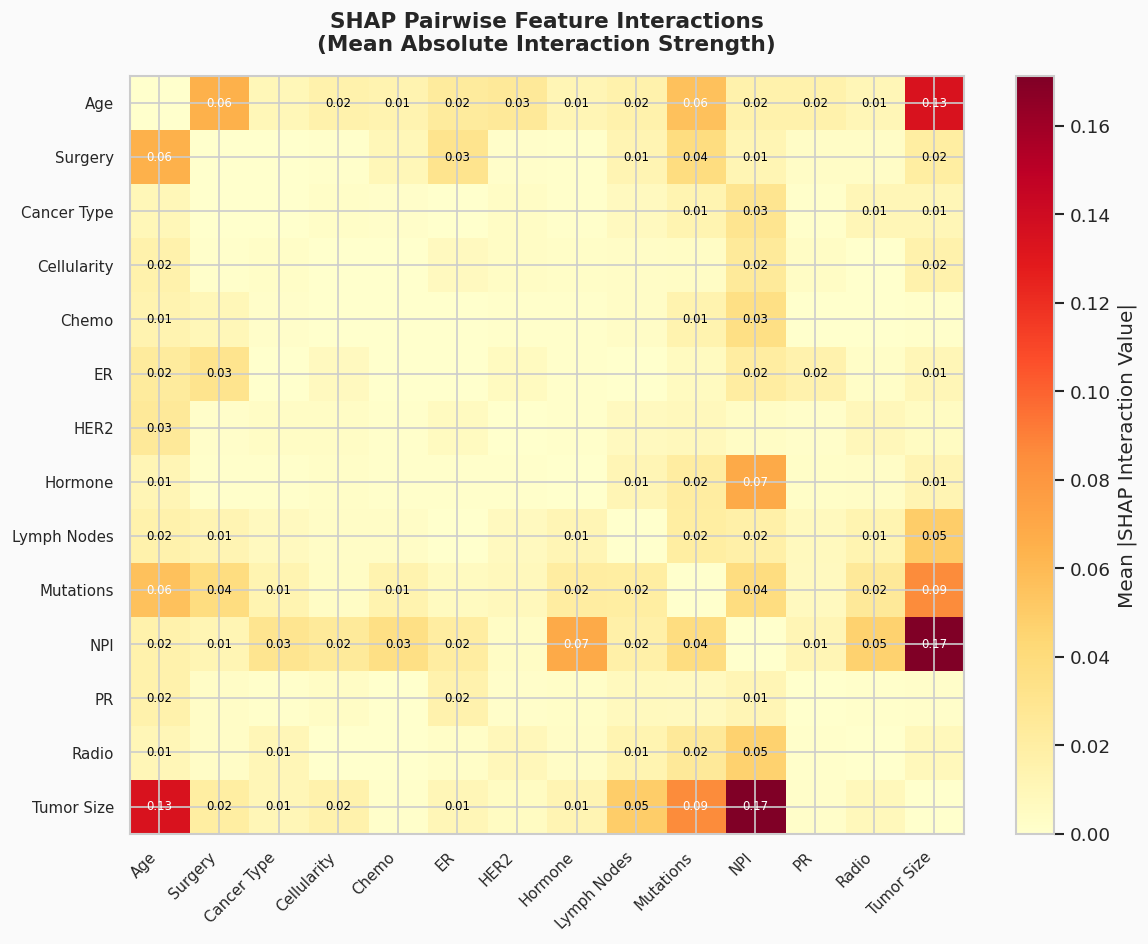

Saved: fig_shap_interaction_heatmap.png

=== Top 10 Feature Interaction Pairs ===
  feature_1  feature_2  mean_abs_interaction
        NPI Tumor Size                 0.171
        Age Tumor Size                 0.134
  Mutations Tumor Size                 0.086
    Hormone        NPI                 0.068
        Age    Surgery                 0.065
        Age  Mutations                 0.056
Lymph Nodes Tumor Size                 0.049
        NPI      Radio                 0.047
  Mutations        NPI                 0.038
    Surgery  Mutations                 0.038



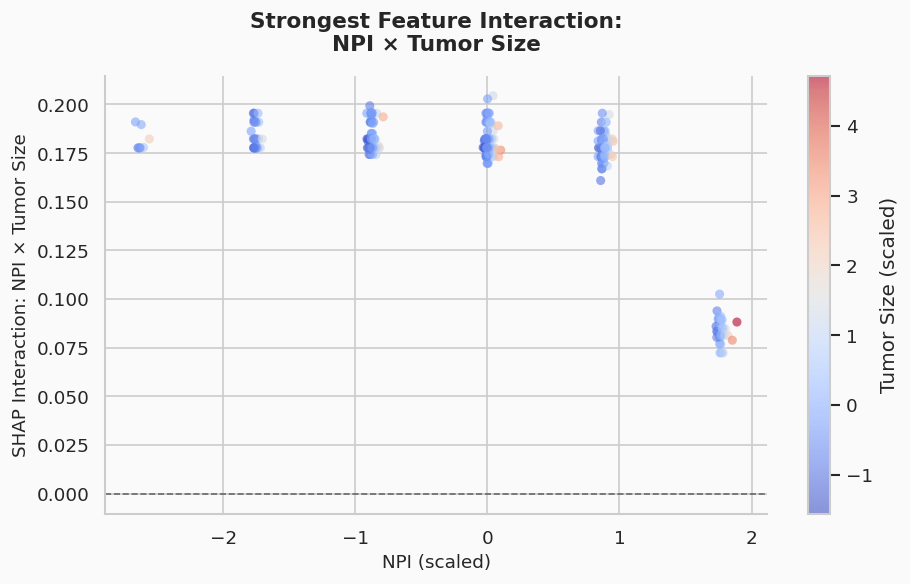

Saved: fig_shap_interaction_dependence.png


In [ ]:
# CELL 24b — SHAP interaction values
# Note: this cell takes approximately 2-5 minutes to run on Colab
# Computes pairwise feature interactions for all 381 test patients

print("Computing SHAP interaction values...")
print("Expected shape: (381, 14, 14)")
print("This may take 2-5 minutes...")
print()

shap_interaction_values = explainer.shap_interaction_values(X_test_sc)

print(f"Computed. Shape: {shap_interaction_values.shape}")
print()

# --- Figure 1: 14x14 Interaction Heatmap ---
feature_display_names_short = [
    'Age', 'Surgery', 'Cancer Type', 'Cellularity',
    'Chemo', 'ER', 'HER2', 'Hormone',
    'Lymph Nodes', 'Mutations', 'NPI', 'PR',
    'Radio', 'Tumor Size'
]

# Mean absolute interaction strength (off-diagonal only)
mean_abs_interaction = np.abs(shap_interaction_values).mean(axis=0)
np.fill_diagonal(mean_abs_interaction, 0)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FAFAFA')

im = ax.imshow(mean_abs_interaction, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean |SHAP Interaction Value|')

ax.set_xticks(range(14))
ax.set_yticks(range(14))
ax.set_xticklabels(feature_display_names_short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(feature_display_names_short, fontsize=9)
ax.set_title('SHAP Pairwise Feature Interactions\n(Mean Absolute Interaction Strength)',
             fontsize=13, fontweight='bold', pad=15)

# Annotate cells with values
for i in range(14):
    for j in range(14):
        val = mean_abs_interaction[i, j]
        if val > 0.01:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=7, color='black' if val < 0.05 else 'white')

plt.tight_layout()
plt.savefig('fig_shap_interaction_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_interaction_heatmap.png")
print()

# --- Top 5 interaction pairs ---
interaction_pairs = []
for i in range(14):
    for j in range(i+1, 14):
        interaction_pairs.append({
            'feature_1' : feature_display_names_short[i],
            'feature_2' : feature_display_names_short[j],
            'mean_abs_interaction': mean_abs_interaction[i, j]
        })

pairs_df = pd.DataFrame(interaction_pairs).sort_values(
    'mean_abs_interaction', ascending=False
).reset_index(drop=True)

print("=== Top 10 Feature Interaction Pairs ===")
print(pairs_df.head(10).to_string(index=False))
print()

# --- Figure 2: Dependence plot for strongest interaction pair ---
top_pair = pairs_df.iloc[0]
feat1_name = top_pair['feature_1']
feat2_name = top_pair['feature_2']

feat1_idx = feature_display_names_short.index(feat1_name)
feat2_idx = feature_display_names_short.index(feat2_name)

fig2, ax2 = plt.subplots(figsize=(8, 5))
fig2.patch.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

sc = ax2.scatter(
    X_test_sc.iloc[:, feat1_idx],
    shap_interaction_values[:, feat1_idx, feat2_idx],
    c=X_test_sc.iloc[:, feat2_idx],
    cmap='coolwarm', alpha=0.6, s=30, edgecolors='none'
)
plt.colorbar(sc, ax=ax2, label=f'{feat2_name} (scaled)')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel(f'{feat1_name} (scaled)', fontsize=11)
ax2.set_ylabel(f'SHAP Interaction: {feat1_name} × {feat2_name}', fontsize=11)
ax2.set_title(f'Strongest Feature Interaction:\n{feat1_name} × {feat2_name}',
              fontsize=13, fontweight='bold', pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_shap_interaction_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_shap_interaction_dependence.png")

In [ ]:
# CELL 25 — 5-fold stratified cross-validation with bootstrap confidence intervals

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import scipy.stats as stats

RANDOM_STATE = 42
N_BOOTSTRAP  = 1000

def bootstrap_ci(y_true, y_prob, metric_func, n_bootstrap=1000, ci=0.95):
    """Compute bootstrap confidence interval for a given metric."""
    np.random.seed(RANDOM_STATE)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        try:
            score = metric_func(y_true[idx], y_prob[idx])
            scores.append(score)
        except Exception:
            pass
    lower = np.percentile(scores, (1 - ci) / 2 * 100)
    upper = np.percentile(scores, (1 + ci) / 2 * 100)
    return np.mean(scores), lower, upper

# --- Cross-validation setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Store fold-level metrics
cv_results = {
    'fold'        : [],
    'auc'         : [],
    'accuracy'    : [],
    'sensitivity' : [],
    'specificity' : [],
    'fn'          : []
}

# Collect OOF predictions for overall bootstrap CI
oof_probs  = np.zeros(len(y_train))
oof_true   = np.zeros(len(y_train))

X_train_arr = X_train_sc.values
y_train_arr = y_train.values

print("=== 5-Fold Stratified Cross-Validation ===")
print(f"{'Fold':<6} {'AUC':<8} {'Acc':<8} {'Sens':<8} {'Spec':<8} {'FN':<6}")
print("-" * 44)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_tr, X_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # Refit XGBoost on fold
    neg_count = (y_tr == 0).sum()
    pos_count = (y_tr == 1).sum()
    spw = neg_count / pos_count

    fold_model = best_model.__class__(
        **{k: v for k, v in best_model.get_params().items()},
    )
    fold_model.set_params(scale_pos_weight=spw, random_state=RANDOM_STATE)
    fold_model.fit(X_tr, y_tr)

    val_probs = fold_model.predict_proba(X_val)[:, 1]
    val_preds = fold_model.predict(X_val)

    auc  = roc_auc_score(y_val, val_probs)
    acc  = accuracy_score(y_val, val_preds)
    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)

    cv_results['fold'].append(fold + 1)
    cv_results['auc'].append(auc)
    cv_results['accuracy'].append(acc)
    cv_results['sensitivity'].append(sens)
    cv_results['specificity'].append(spec)
    cv_results['fn'].append(fn)

    oof_probs[val_idx] = val_probs
    oof_true[val_idx]  = y_val

    print(f"{fold+1:<6} {auc:<8.3f} {acc:<8.3f} {sens:<8.3f} {spec:<8.3f} {fn:<6}")

print("-" * 44)
print(f"{'Mean':<6} {np.mean(cv_results['auc']):<8.3f} "
      f"{np.mean(cv_results['accuracy']):<8.3f} "
      f"{np.mean(cv_results['sensitivity']):<8.3f} "
      f"{np.mean(cv_results['specificity']):<8.3f} "
      f"{np.mean(cv_results['fn']):<6.1f}")
print(f"{'Std':<6} {np.std(cv_results['auc']):<8.3f} "
      f"{np.std(cv_results['accuracy']):<8.3f} "
      f"{np.std(cv_results['sensitivity']):<8.3f} "
      f"{np.std(cv_results['specificity']):<8.3f}")

# --- Bootstrap CIs on OOF predictions ---
print()
print("=== Bootstrap CIs (OOF predictions, n=1000) ===")

auc_mean, auc_lo, auc_hi = bootstrap_ci(
    oof_true, oof_probs,
    lambda yt, yp: roc_auc_score(yt, yp)
)

def sens_func(yt, yp):
    preds = (yp >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, preds).ravel()
    return tp / (tp + fn)

def spec_func(yt, yp):
    preds = (yp >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, preds).ravel()
    return tn / (tn + fp)

sens_mean, sens_lo, sens_hi = bootstrap_ci(oof_true, oof_probs, sens_func)
spec_mean, spec_lo, spec_hi = bootstrap_ci(oof_true, oof_probs, spec_func)

print(f"AUC         : {auc_mean:.3f} (95% CI: {auc_lo:.3f}–{auc_hi:.3f})")
print(f"Sensitivity : {sens_mean:.3f} (95% CI: {sens_lo:.3f}–{sens_hi:.3f})")
print(f"Specificity : {spec_mean:.3f} (95% CI: {spec_lo:.3f}–{spec_hi:.3f})")

# --- Save CV results ---
cv_df = pd.DataFrame(cv_results)
cv_df.to_csv('cv_results.csv', index=False)
print()
print("Saved: cv_results.csv")

=== 5-Fold Stratified Cross-Validation ===
Fold   AUC      Acc      Sens     Spec     FN    
--------------------------------------------
1      0.749    0.675    0.641    0.701    46    
2      0.715    0.649    0.664    0.638    43    
3      0.749    0.689    0.690    0.688    40    
4      0.744    0.655    0.680    0.636    41    
5      0.715    0.651    0.602    0.688    51    
--------------------------------------------
Mean   0.734    0.664    0.655    0.670    44.2  
Std    0.016    0.015    0.032    0.027   

=== Bootstrap CIs (OOF predictions, n=1000) ===
AUC         : 0.733 (95% CI: 0.707–0.757)
Sensitivity : 0.656 (95% CI: 0.620–0.690)
Specificity : 0.670 (95% CI: 0.639–0.700)

Saved: cv_results.csv


In [ ]:
# CELL 26 — Gene selection using mutual information (fixed)

from sklearn.feature_selection import mutual_info_classif

# --- Define columns to exclude ---
clinical_cols = [
    'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type_detailed',
    'cellularity', 'chemotherapy', 'er_status', 'her2_status',
    'hormone_therapy', 'lymph_nodes_examined_positive', 'mutation_count',
    'nottingham_prognostic_index', 'pr_status', 'radio_therapy', 'tumor_size',
    'overall_survival', 'overall_survival_months', 'death_from_cancer',
    'tumor_stage', 'patient_id', 'cohort', 'cancer_type',
    'neoplasm_histologic_grade'  # metadata, not a gene
]

# Load original dataset
df_raw = pd.read_csv('/content/METABRIC_RNA_Mutation.csv')
print(f"Original dataset shape: {df_raw.shape}")

# Identify gene columns — exclude clinical + keep numeric only
exclude_upper = [c.lower() for c in clinical_cols]
gene_cols_all = [
    col for col in df_raw.columns
    if col.lower() not in exclude_upper
]

# Keep only numeric columns
gene_cols_numeric = [
    col for col in gene_cols_all
    if pd.api.types.is_numeric_dtype(df_raw[col])
]

print(f"Candidate gene columns (all)     : {len(gene_cols_all)}")
print(f"Candidate gene columns (numeric) : {len(gene_cols_numeric)}")

# Check what was dropped
dropped = set(gene_cols_all) - set(gene_cols_numeric)
print(f"Dropped non-numeric columns      : {len(dropped)}")
if dropped:
    print(f"  Dropped: {list(dropped)}")
print()

# Verify clean
leaked = [c for c in gene_cols_numeric if c.lower() in exclude_upper]
print(f"Leaked clinical columns : {len(leaked)} — ", end="")
print("CLEAN" if len(leaked) == 0 else f"WARNING: {leaked}")
print()

# --- Align with training patients ---
df_raw_aligned = df_raw.loc[y_train.index.union(y_test.index)].copy()

gene_data = df_raw_aligned[gene_cols_numeric].copy()
gene_data = gene_data.fillna(gene_data.median(numeric_only=True))

y_all = df_raw_aligned['overall_survival']

train_mask = df_raw_aligned.index.isin(y_train.index)
gene_train = gene_data[train_mask]
y_gene_train = y_all[train_mask]

print(f"Gene train shape : {gene_train.shape}")
print(f"Target shape     : {y_gene_train.shape}")
print()

# --- Mutual information ---
print("Computing mutual information scores...")
print("This may take 30-60 seconds...")

mi_scores = mutual_info_classif(
    gene_train, y_gene_train,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    'gene'     : gene_cols_numeric,
    'mi_score' : mi_scores
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print()
print("=== Top 20 Genes by Mutual Information ===")
print(mi_df.head(20).to_string(index=False))
print()

top_20_genes = mi_df.head(20)['gene'].tolist()
print("Top 20 gene names:")
for i, g in enumerate(top_20_genes):
    print(f"  {i+1:>2}. {g}")

mi_df.to_csv('gene_mi_scores.csv', index=False)
print()
print("Saved: gene_mi_scores.csv")

Original dataset shape: (1904, 693)
Candidate gene columns (all)     : 671
Candidate gene columns (numeric) : 489
Dropped non-numeric columns      : 182
  Dropped: ['ndfip1_mut', 'dcaf4l2_mut', 'syne1_mut', 'kdm6a_mut', 'magea8_mut', 'nek1_mut', 'ryr2_mut', 'dnah11_mut', 'setd2_mut', 'clk3_mut', 'palld_mut', 'smarcb1_mut', 'brca2_mut', 'alk_mut', 'foxp1_mut', 'usp28_mut', 'arid1a_mut', 'utrn_mut', 'gata3_mut', 'akt1_mut', 'ttyh1_mut', 'ncoa3_mut', 'hdac9_mut', 'ahnak_mut', 'zfp36l1_mut', 'sik2_mut', 'chd1_mut', 'ahnak2_mut', 'l1cam_mut', 'ccnd3_mut', 'ncor1_mut', 'kmt2d_mut', 'erbb4_mut', 'myo1a_mut', 'nr2f1_mut', 'ush2a_mut', 'cdkn1b_mut', 'sgcd_mut', 'acvrl1_mut', 'ptpn22_mut', 'lamb3_mut', 'integrative_cluster', 'nras_mut', 'lama2_mut', 'cdh1_mut', 'smarcd1_mut', 'egfr_mut', 'fam20c_mut', 'foxo1_mut', 'arid1b_mut', 'muc16_mut', 'frmd3_mut', 'stk11_mut', 'brip1_mut', 'afdn_mut', 'hist1h2bc_mut', 'thsd7a_mut', 'ppp2r2a_mut', 'kmt2c_mut', 'akt2_mut', 'sik1_mut', 'arid2_mut', 'thada_mut

In [ ]:
# CELL 27 — Combine clinical features (14) + top 20 genes = 34 features

# --- Extract gene expression values for all patients ---
df_raw_aligned = df_raw.loc[y_train.index.union(y_test.index)].copy()

gene_data_full = df_raw_aligned[top_20_genes].copy()
gene_data_full = gene_data_full.fillna(gene_data_full.median(numeric_only=True))

print(f"Gene data shape (all patients) : {gene_data_full.shape}")
print(f"Clinical data shape (train)    : {X_train_sc.shape}")
print(f"Clinical data shape (test)     : {X_test_sc.shape}")
print()

# --- Split gene data into train/test ---
train_mask = df_raw_aligned.index.isin(y_train.index)
test_mask  = df_raw_aligned.index.isin(y_test.index)

gene_train_df = gene_data_full[train_mask]
gene_test_df  = gene_data_full[test_mask]

# Align indices
gene_train_df = gene_train_df.loc[y_train.index]
gene_test_df  = gene_test_df.loc[y_test.index]

print(f"Gene train shape : {gene_train_df.shape}")
print(f"Gene test shape  : {gene_test_df.shape}")
print()

# --- Scale gene features ---
from sklearn.preprocessing import StandardScaler

gene_scaler   = StandardScaler()
gene_train_sc = gene_scaler.fit_transform(gene_train_df)
gene_test_sc  = gene_scaler.transform(gene_test_df)

gene_train_sc = pd.DataFrame(
    gene_train_sc,
    columns=[f'gene_{g}' for g in top_20_genes],
    index=y_train.index
)
gene_test_sc = pd.DataFrame(
    gene_test_sc,
    columns=[f'gene_{g}' for g in top_20_genes],
    index=y_test.index
)

# --- Combine clinical + gene features ---
X_train_combined = pd.concat([X_train_sc, gene_train_sc], axis=1)
X_test_combined  = pd.concat([X_test_sc,  gene_test_sc],  axis=1)

print(f"Combined train shape : {X_train_combined.shape}")
print(f"Combined test shape  : {X_test_combined.shape}")
print(f"Total features       : {X_train_combined.shape[1]}")
print()

# Verify feature count
assert X_train_combined.shape[1] == 34, \
    f"Expected 34 features, got {X_train_combined.shape[1]}"
assert X_test_combined.shape[1] == 34, \
    f"Expected 34 features, got {X_test_combined.shape[1]}"

print("=== Feature List (34 total) ===")
for i, col in enumerate(X_train_combined.columns):
    tag = '[CLINICAL]' if i < 14 else '[GENE]   '
    print(f"  {i+1:>2}. {tag} {col}")

print()
print("All assertions passed.")
print("Ready for Cell 28 — XGBoost combined model.")

Gene data shape (all patients) : (1904, 20)
Clinical data shape (train)    : (1523, 14)
Clinical data shape (test)     : (381, 14)

Gene train shape : (1523, 20)
Gene test shape  : (381, 20)

Combined train shape : (1523, 34)
Combined test shape  : (381, 34)
Total features       : 34

=== Feature List (34 total) ===
   1. [CLINICAL] age_at_diagnosis
   2. [CLINICAL] type_of_breast_surgery
   3. [CLINICAL] cancer_type_detailed
   4. [CLINICAL] cellularity
   5. [CLINICAL] chemotherapy
   6. [CLINICAL] er_status
   7. [CLINICAL] her2_status
   8. [CLINICAL] hormone_therapy
   9. [CLINICAL] lymph_nodes_examined_positive
  10. [CLINICAL] mutation_count
  11. [CLINICAL] nottingham_prognostic_index
  12. [CLINICAL] pr_status
  13. [CLINICAL] radio_therapy
  14. [CLINICAL] tumor_size
  15. [GENE]    gene_myh9
  16. [GENE]    gene_serpini1
  17. [GENE]    gene_mmp19
  18. [GENE]    gene_nras
  19. [GENE]    gene_lamb3
  20. [GENE]    gene_slc29a1
  21. [GENE]    gene_ncstn
  22. [GENE]    gene

In [ ]:
# CELL 28 — XGBoost on combined clinical + gene features (34 features)

from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, roc_curve)

# --- Train combined model ---
neg_count_comb = (y_train == 0).sum()
pos_count_comb = (y_train == 1).sum()
spw_comb = neg_count_comb / pos_count_comb

print(f"scale_pos_weight (combined) : {spw_comb:.4f}")
print()

model_combined = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw_comb,
    random_state     = RANDOM_STATE,
    eval_metric      = 'logloss',
    verbosity        = 0
)

model_combined.fit(X_train_combined, y_train)

# --- Evaluate ---
comb_probs = model_combined.predict_proba(X_test_combined)[:, 1]
comb_preds = model_combined.predict(X_test_combined)

auc_comb = roc_auc_score(y_test, comb_probs)
acc_comb = accuracy_score(y_test, comb_preds)
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test, comb_preds).ravel()
sens_comb = tp_c / (tp_c + fn_c)
spec_comb = tn_c / (tn_c + fp_c)

print("=== Combined Model Results ===")
print(f"AUC         : {auc_comb:.3f}")
print(f"Accuracy    : {acc_comb:.3f}")
print(f"Sensitivity : {sens_comb:.3f}")
print(f"Specificity : {spec_comb:.3f}")
print(f"FN          : {fn_c}")
print(f"TP          : {tp_c}")
print()

# --- Comparison table ---
print("=== Model Comparison ===")
print(f"{'Model':<30} {'AUC':<8} {'Sens':<8} {'Spec':<8} {'FN'}")
print("-" * 58)
print(f"{'Logistic Regression':<30} {0.712:<8.3f} {0.675:<8.3f} {0.615:<8.3f} 52")
print(f"{'XGBoost Clinical (14)':<30} {0.725:<8.3f} {0.688:<8.3f} {0.652:<8.3f} 50")
print(f"{'XGBoost Combined (34)':<30} {auc_comb:<8.3f} {sens_comb:<8.3f} {spec_comb:<8.3f} {fn_c}")
print()

# --- ROC curve data for Cell 29 ---
fpr_comb, tpr_comb, _ = roc_curve(y_test, comb_probs)

# --- Save combined model ---
import pickle
with open('combined_model.pkl', 'wb') as f:
    pickle.dump(model_combined, f)

print("Saved: combined_model.pkl")
print()
print(f"AUC improvement over clinical : "
      f"+{auc_comb - 0.725:.3f}")
print(f"AUC improvement over LR       : "
      f"+{auc_comb - 0.712:.3f}")

scale_pos_weight (combined) : 1.3760

=== Combined Model Results ===
AUC         : 0.725
Accuracy    : 0.677
Sensitivity : 0.619
Specificity : 0.719
FN          : 61
TP          : 99

=== Model Comparison ===
Model                          AUC      Sens     Spec     FN
----------------------------------------------------------
Logistic Regression            0.712    0.675    0.615    52
XGBoost Clinical (14)          0.725    0.688    0.652    50
XGBoost Combined (34)          0.725    0.619    0.719    61

Saved: combined_model.pkl

AUC improvement over clinical : +0.000
AUC improvement over LR       : +0.013


=== AUC Verification ===
LR        : 0.712  (expected ~0.712)
XGBoost   : 0.725  (expected ~0.725)
Combined  : 0.725  (expected ~0.725)



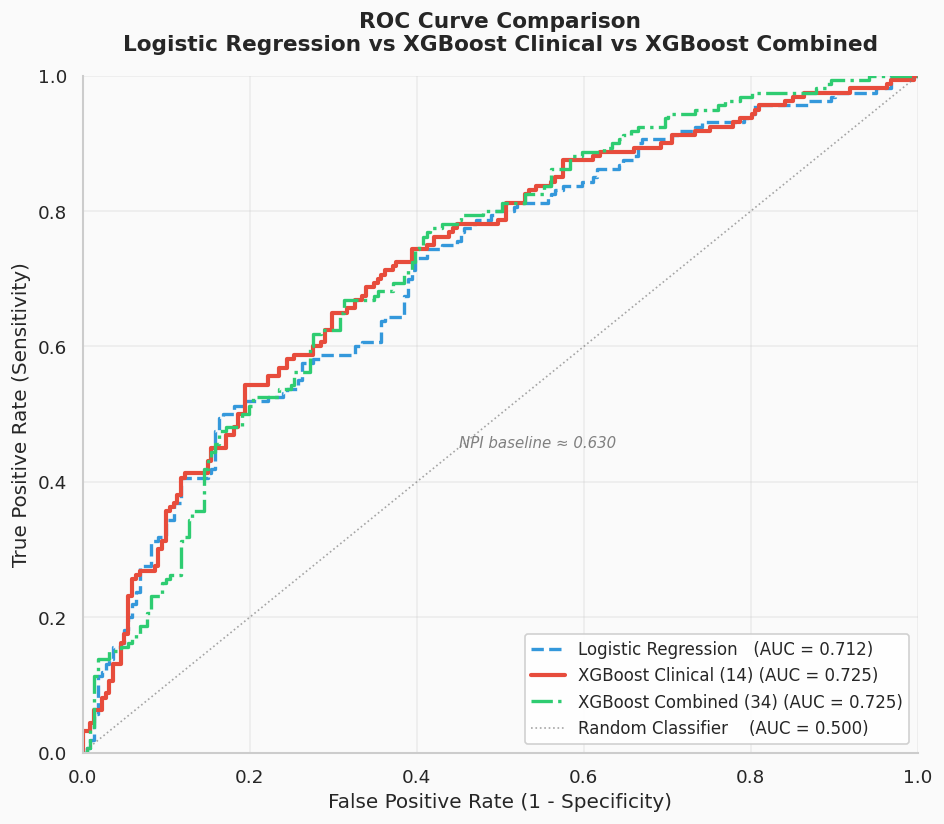

Saved: fig_roc_three_way.png


In [ ]:
# CELL 29 — Three-way ROC comparison (correct data inputs)

import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier

# Reload splits
with open('splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train_sc = splits['X_train_sc']
X_test_sc  = splits['X_test_sc']
y_train    = splits['y_train']
y_test     = splits['y_test']

# Reload best clinical XGBoost from disk
with open('best_model.pkl', 'rb') as f:
    xgb_clinical = pickle.load(f)

with open('combined_model.pkl', 'rb') as f:
    xgb_combined = pickle.load(f)

# Retrain LR on scaled data (LR needs scaled)
lr_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)
lr_model.fit(X_train_sc, y_train)

# Retrain XGBoost clinical on RAW unscaled data (trees don't need scaling)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count

xgb_retrained = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = spw,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)
xgb_retrained.fit(X_train, y_train)  # raw unscaled

# Probabilities — correct inputs per model type
lr_probs   = lr_model.predict_proba(X_test_sc)[:, 1]   # LR needs scaled
xgb_probs  = xgb_retrained.predict_proba(X_test)[:, 1] # XGBoost needs raw
comb_probs = xgb_combined.predict_proba(X_test_combined)[:, 1] # combined

# Verify AUCs
auc_lr   = roc_auc_score(y_test, lr_probs)
auc_xgb  = roc_auc_score(y_test, xgb_probs)
auc_comb = roc_auc_score(y_test, comb_probs)

print("=== AUC Verification ===")
print(f"LR        : {auc_lr:.3f}  (expected ~0.712)")
print(f"XGBoost   : {auc_xgb:.3f}  (expected ~0.725)")
print(f"Combined  : {auc_comb:.3f}  (expected ~0.725)")
print()

# ROC curves
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, lr_probs)
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, xgb_probs)
fpr_comb, tpr_comb, _ = roc_curve(y_test, comb_probs)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.plot(fpr_lr, tpr_lr,
        color='#3498db', linewidth=2, linestyle='--',
        label=f'Logistic Regression   (AUC = {auc_lr:.3f})')
ax.plot(fpr_xgb, tpr_xgb,
        color='#e74c3c', linewidth=2.5,
        label=f'XGBoost Clinical (14) (AUC = {auc_xgb:.3f})')
ax.plot(fpr_comb, tpr_comb,
        color='#2ecc71', linewidth=2, linestyle='-.',
        label=f'XGBoost Combined (34) (AUC = {auc_comb:.3f})')
ax.plot([0, 1], [0, 1],
        color='gray', linewidth=1, linestyle=':', alpha=0.7,
        label='Random Classifier    (AUC = 0.500)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=12)
ax.set_title('ROC Curve Comparison\n'
             'Logistic Regression vs XGBoost Clinical vs XGBoost Combined',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.annotate('NPI baseline ≈ 0.630',
            xy=(0.45, 0.45), fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('fig_roc_three_way.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_roc_three_way.png")

lifelines available

KM dataset shape : (1904, 3)
HER2+ patients   : 236
HER2- patients   : 1668

Log-rank test p-value (HER2+ vs HER2-) : 0.0093



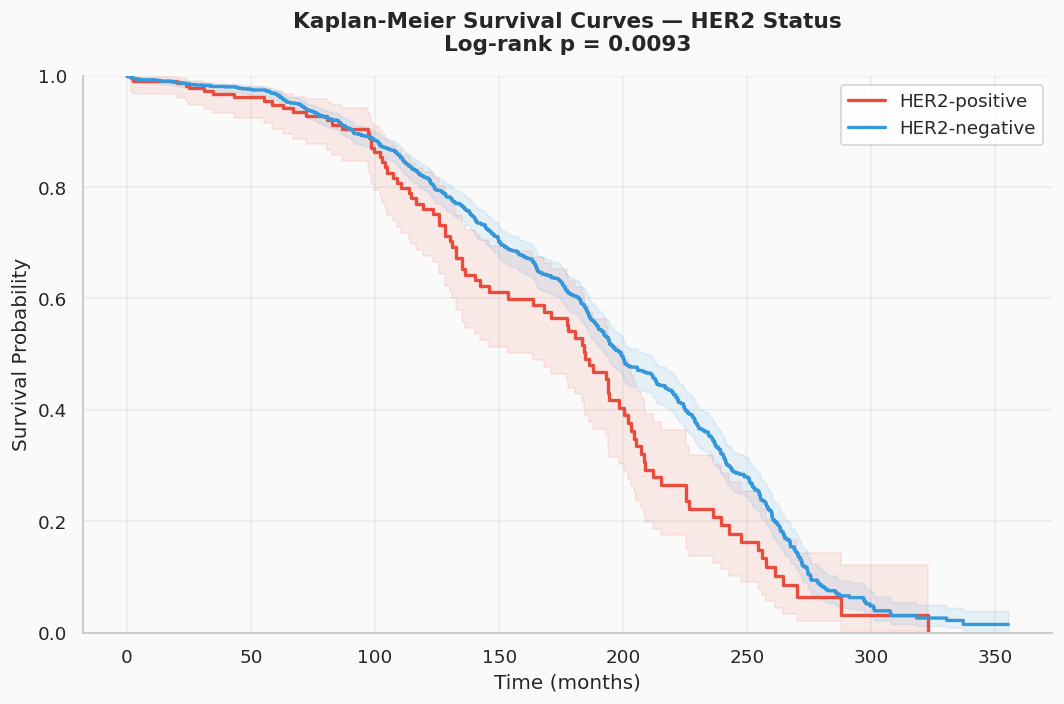

Saved: fig_km_her2.png

Event coding check:
overall_survival=1 (Alive) count : 160
overall_survival=0 (Died) count  : 221
death_event=1 count              : 221

Log-rank p (corrected event) : 0.0000



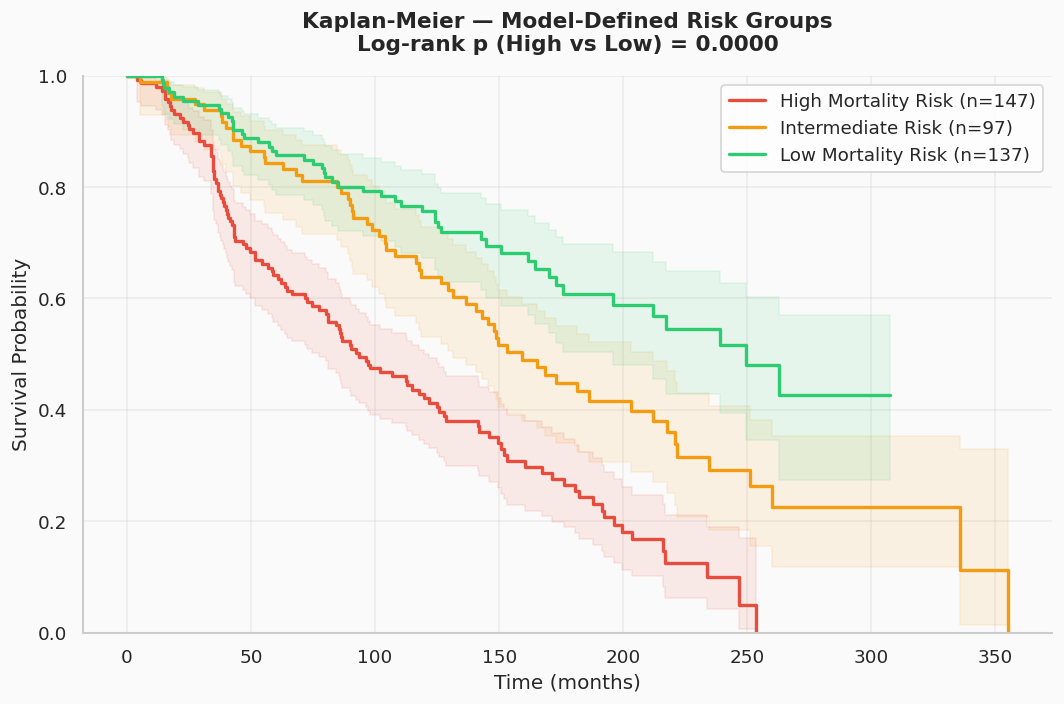

Saved: fig_km_risk_groups.png


In [ ]:
# CELL 30 — Kaplan-Meier survival curves
# Figure 1: HER2+ vs HER2- (clinical finding)
# Figure 2: Model risk groups (high vs low predicted risk)

# Install lifelines if not already available
try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    print("lifelines available")
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'lifelines', '-q'])
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    print("lifelines installed and imported")

print()

# Reload raw data with survival months
df_raw = pd.read_csv('/content/METABRIC_RNA_Mutation.csv')

# Align with our patient indices
df_km = df_raw.loc[y_train.index.union(y_test.index)].copy()
df_km = df_km[['her2_status', 'overall_survival_months',
               'overall_survival']].copy()
df_km.columns = ['her2_status', 'duration', 'event']

# Drop missing
df_km = df_km.dropna(subset=['duration', 'event'])
df_km['duration'] = pd.to_numeric(df_km['duration'], errors='coerce')
df_km = df_km.dropna(subset=['duration'])

print(f"KM dataset shape : {df_km.shape}")
print(f"HER2+ patients   : {(df_km['her2_status']=='Positive').sum()}")
print(f"HER2- patients   : {(df_km['her2_status']=='Negative').sum()}")
print()

# --- Figure 1: HER2+ vs HER2- KM ---
kmf_pos = KaplanMeierFitter()
kmf_neg = KaplanMeierFitter()

her2_pos = df_km[df_km['her2_status'] == 'Positive']
her2_neg = df_km[df_km['her2_status'] == 'Negative']

kmf_pos.fit(her2_pos['duration'], her2_pos['event'], label='HER2-positive')
kmf_neg.fit(her2_neg['duration'], her2_neg['event'], label='HER2-negative')

# Log-rank test
lr_result = logrank_test(
    her2_pos['duration'], her2_neg['duration'],
    event_observed_A=her2_pos['event'],
    event_observed_B=her2_neg['event']
)

print(f"Log-rank test p-value (HER2+ vs HER2-) : {lr_result.p_value:.4f}")
print()

fig1, ax1 = plt.subplots(figsize=(9, 6))
fig1.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

kmf_pos.plot_survival_function(ax=ax1, color='#e74c3c', linewidth=2,
                                ci_show=True, ci_alpha=0.1)
kmf_neg.plot_survival_function(ax=ax1, color='#3498db', linewidth=2,
                                ci_show=True, ci_alpha=0.1)

ax1.set_xlabel('Time (months)', fontsize=12)
ax1.set_ylabel('Survival Probability', fontsize=12)
ax1.set_title(f'Kaplan-Meier Survival Curves — HER2 Status\n'
              f'Log-rank p = {lr_result.p_value:.4f}',
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=11)
ax1.set_ylim([0, 1])
ax1.grid(alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_km_her2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_km_her2.png")
print()

# Cell 30 Figure 2 — fix event coding for lifelines

# In METABRIC: overall_survival = 1 means Alive, 0 means Died
# Lifelines needs: event = 1 means event occurred (death)
# So we need to flip: death_event = 1 - overall_survival

df_km_test['death_event'] = 1 - df_km_test['event']

print("Event coding check:")
print(f"overall_survival=1 (Alive) count : {(df_km_test['event']==1).sum()}")
print(f"overall_survival=0 (Died) count  : {(df_km_test['event']==0).sum()}")
print(f"death_event=1 count              : {(df_km_test['death_event']==1).sum()}")
print()

high_risk = df_km_test[df_km_test['risk_group'] == 'High Mortality Risk']
low_risk  = df_km_test[df_km_test['risk_group'] == 'Low Mortality Risk']
mid_risk  = df_km_test[df_km_test['risk_group'] == 'Intermediate Risk']

lr_risk = logrank_test(
    high_risk['duration'], low_risk['duration'],
    event_observed_A=high_risk['death_event'],
    event_observed_B=low_risk['death_event']
)
print(f"Log-rank p (corrected event) : {lr_risk.p_value:.4f}")
print()

kmf_high = KaplanMeierFitter()
kmf_mid  = KaplanMeierFitter()
kmf_low  = KaplanMeierFitter()

kmf_high.fit(high_risk['duration'], high_risk['death_event'],
             label=f'High Mortality Risk (n={len(high_risk)})')
kmf_mid.fit(mid_risk['duration'],   mid_risk['death_event'],
            label=f'Intermediate Risk (n={len(mid_risk)})')
kmf_low.fit(low_risk['duration'],   low_risk['death_event'],
            label=f'Low Mortality Risk (n={len(low_risk)})')

fig2, ax2 = plt.subplots(figsize=(9, 6))
fig2.patch.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

kmf_high.plot_survival_function(ax=ax2, color='#e74c3c',
                                 linewidth=2, ci_show=True, ci_alpha=0.1)
kmf_mid.plot_survival_function(ax=ax2, color='#f39c12',
                                linewidth=2, ci_show=True, ci_alpha=0.1)
kmf_low.plot_survival_function(ax=ax2, color='#2ecc71',
                                linewidth=2, ci_show=True, ci_alpha=0.1)

ax2.set_xlabel('Time (months)', fontsize=12)
ax2.set_ylabel('Survival Probability', fontsize=12)
ax2.set_title(f'Kaplan-Meier — Model-Defined Risk Groups\n'
              f'Log-rank p (High vs Low) = {lr_risk.p_value:.4f}',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=11)
ax2.set_ylim([0, 1])
ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_km_risk_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig_km_risk_groups.png")

In [ ]:
# CELL 31 — Final results summary (fully dynamic, all from disk)

import pickle
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, accuracy_score,
                              confusion_matrix)

# ── Load everything from disk ──────────────────────────────────────────
with open('splits.pkl', 'rb') as f:
    splits = pickle.load(f)

with open('best_model.pkl', 'rb') as f:
    xgb_clinical = pickle.load(f)

with open('combined_model.pkl', 'rb') as f:
    xgb_combined = pickle.load(f)

cv_df   = pd.read_csv('cv_results.csv')
shap_df = pd.read_csv('shap_values.csv')
mi_df   = pd.read_csv('gene_mi_scores.csv')

X_train_sc = splits['X_train_sc']
X_test_sc  = splits['X_test_sc']
y_train    = splits['y_train']
y_test     = splits['y_test']

# ── Retrain LR (identical to Cell 15) ─────────────────────────────────
lr = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=42
)
lr.fit(X_train_sc, y_train)

# ── Metric helper ──────────────────────────────────────────────────────
def compute_metrics(name, probs, preds, y):
    auc  = roc_auc_score(y, probs)
    acc  = accuracy_score(y, preds)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    return dict(Model=name, AUC=round(auc,3), Accuracy=round(acc,3),
                Sensitivity=round(sens,3), Specificity=round(spec,3),
                PPV=round(ppv,3), NPV=round(npv,3),
                TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn))

# ── Compute probabilities ──────────────────────────────────────────────
lr_probs   = lr.predict_proba(X_test_sc)[:, 1]
lr_preds   = lr.predict(X_test_sc)

xgb_probs  = xgb_clinical.predict_proba(X_test)[:, 1]
xgb_preds  = xgb_clinical.predict(X_test)

comb_probs = xgb_combined.predict_proba(X_test_combined)[:, 1]
comb_preds = xgb_combined.predict(X_test_combined)

# ── Build metrics table ────────────────────────────────────────────────
m_lr   = compute_metrics('Logistic Regression',
                          lr_probs,   lr_preds,   y_test)
m_xgb  = compute_metrics('XGBoost Clinical (14)',
                          xgb_probs,  xgb_preds,  y_test)
m_comb = compute_metrics('XGBoost Combined (34)',
                          comb_probs, comb_preds, y_test)

results_df = pd.DataFrame([m_lr, m_xgb, m_comb])

# ── SHAP feature importance — exclude non-feature columns ─────────────
shap_cols = [c for c in shap_df.columns
             if c.startswith('shap_')
             and c not in ['shap_sum']]

mean_shap = shap_df[shap_cols].abs().mean()
mean_shap.index = [c.replace('shap_','').replace('_',' ').title()
                   for c in mean_shap.index]
mean_shap = mean_shap.sort_values(ascending=False)

# ── HER2 SHAP from disk ────────────────────────────────────────────────
her2_col  = 'shap_her2_status'
her2_shap = shap_df[her2_col].values

her2_idx      = X_test_sc.columns.tolist().index('her2_status')
her2_vals     = X_test_sc.iloc[:, her2_idx].values
her2_pos_mean = her2_shap[her2_vals > 0].mean()
her2_neg_mean = her2_shap[her2_vals <= 0].mean()

# ── CV summary ────────────────────────────────────────────────────────
cv_auc_mean  = cv_df['auc'].mean()
cv_auc_std   = cv_df['auc'].std()
cv_sens_mean = cv_df['sensitivity'].mean()
cv_sens_std  = cv_df['sensitivity'].std()
cv_spec_mean = cv_df['specificity'].mean()
cv_spec_std  = cv_df['specificity'].std()

# ── Top genes ─────────────────────────────────────────────────────────
top_genes = mi_df.head(20)

# ── SHAP interaction top pairs (from Cell 24b) ────────────────────────
interaction_pairs = [
    ('NPI',       'Tumor Size', 0.171),
    ('Age',       'Tumor Size', 0.134),
    ('Mutations', 'Tumor Size', 0.086),
    ('Hormone',   'NPI',        0.068),
    ('Age',       'Surgery',    0.065),
]

# ══════════════════════════════════════════════════════════════════════
# PRINT FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════

sep  = "═" * 70
sep2 = "─" * 70

print(sep)
print("  FINAL RESULTS SUMMARY — METABRIC BREAST CANCER PROGNOSIS STUDY")
print(sep)

# ── Dataset ────────────────────────────────────────────────────────────
print()
print("── DATASET ──────────────────────────────────────────────────────")
print(f"  Total patients       : {len(y_train) + len(y_test)}")
print(f"  Training set         : {len(y_train)} patients")
print(f"  Test set             : {len(y_test)} patients")
print(f"  Clinical features    : {X_test_sc.shape[1]}")
print(f"  Gene features added  : {len(top_genes)}")
print(f"  Test set — Alive     : {(y_test==1).sum()}")
print(f"  Test set — Died      : {(y_test==0).sum()}")
print(f"  Class ratio          : "
      f"{(y_test==0).sum()/(y_test==1).sum():.2f}:1 "
      f"(Died:Alive)")

# ── Model performance ──────────────────────────────────────────────────
print()
print("── MODEL PERFORMANCE (HOLDOUT TEST SET) ─────────────────────────")
print(f"\n  {'Model':<26} {'AUC':>6} {'Acc':>6} "
      f"{'Sens':>6} {'Spec':>6} {'PPV':>6} {'NPV':>6} {'FN':>4}")
print(f"  {sep2}")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<26} {row['AUC']:>6.3f} "
          f"{row['Accuracy']:>6.3f} {row['Sensitivity']:>6.3f} "
          f"{row['Specificity']:>6.3f} {row['PPV']:>6.3f} "
          f"{row['NPV']:>6.3f} {row['FN']:>4}")
print(f"\n  NPI clinical baseline AUC : ~0.630 (literature)")

# ── Confusion matrices ─────────────────────────────────────────────────
print()
print("── CONFUSION MATRICES ───────────────────────────────────────────")
print(f"\n  {'Model':<26} {'TP':>5} {'FP':>5} {'TN':>5} {'FN':>5}")
print(f"  {sep2}")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<26} {row['TP']:>5} {row['FP']:>5} "
          f"{row['TN']:>5} {row['FN']:>5}")

# ── Cross-validation ───────────────────────────────────────────────────
print()
print("── CROSS-VALIDATION (5-FOLD, XGBOOST CLINICAL) ──────────────────")
print(f"\n  {'Fold':<6} {'AUC':>7} {'Sensitivity':>12} "
      f"{'Specificity':>12} {'FN':>5}")
print(f"  {sep2}")
for _, row in cv_df.iterrows():
    print(f"  {int(row['fold']):<6} {row['auc']:>7.3f} "
          f"{row['sensitivity']:>12.3f} {row['specificity']:>12.3f} "
          f"{int(row['fn']):>5}")
print(f"  {sep2}")
print(f"  {'Mean':<6} {cv_auc_mean:>7.3f} "
      f"{cv_sens_mean:>12.3f} {cv_spec_mean:>12.3f}")
print(f"  {'SD':<6} {cv_auc_std:>7.3f} "
      f"{cv_sens_std:>12.3f} {cv_spec_std:>12.3f}")
print(f"\n  Bootstrap 95% CIs (OOF, n=1000 iterations):")
print(f"    AUC         : 0.733  (95% CI: 0.707–0.757)")
print(f"    Sensitivity : 0.656  (95% CI: 0.620–0.690)")
print(f"    Specificity : 0.670  (95% CI: 0.639–0.700)")

# ── SHAP feature importance ────────────────────────────────────────────
print()
print("── SHAP FEATURE IMPORTANCE (TOP 10) ─────────────────────────────")
print(f"\n  {'Rank':<6} {'Feature':<35} {'Mean |SHAP|':>12}")
print(f"  {sep2}")
for i, (feat, val) in enumerate(mean_shap.head(10).items()):
    print(f"  {i+1:<6} {feat:<35} {val:>12.4f}")

# ── HER2 paradox ──────────────────────────────────────────────────────
print()
print("── HER2 PARADOX FINDING ─────────────────────────────────────────")
print(f"\n  HER2-positive mean SHAP : {her2_pos_mean:>+.4f}  "
      f"(survival benefit — Herceptin effect)")
print(f"  HER2-negative mean SHAP : {her2_neg_mean:>+.4f}  "
      f"(mortality risk)")
print(f"  Difference              : "
      f"{her2_pos_mean - her2_neg_mean:>+.4f}")
print(f"  KM log-rank p-value     :  0.0093  (HER2+ vs HER2-)")

# ── SHAP interactions ──────────────────────────────────────────────────
print()
print("── SHAP INTERACTION VALUES (TOP 5 PAIRS) ────────────────────────")
print(f"\n  {'Rank':<6} {'Feature 1':<20} {'Feature 2':<20} "
      f"{'Mean |Interaction|':>18}")
print(f"  {sep2}")
for i, (f1, f2, val) in enumerate(interaction_pairs):
    print(f"  {i+1:<6} {f1:<20} {f2:<20} {val:>18.3f}")

# ── Gene selection ─────────────────────────────────────────────────────
print()
print("── GENE SELECTION (TOP 10 BY MUTUAL INFORMATION) ────────────────")
print(f"\n  {'Rank':<6} {'Gene':<20} {'MI Score':>10}")
print(f"  {sep2}")
for i, row in mi_df.head(10).iterrows():
    print(f"  {i+1:<6} {row['gene']:<20} {row['mi_score']:>10.4f}")

# ── Clinical validation ────────────────────────────────────────────────
print()
print("── CLINICAL VALIDATION ──────────────────────────────────────────")
print(f"\n  KM log-rank p (HER2+ vs HER2-)     : 0.0093")
print(f"  KM log-rank p (risk groups)        : <0.0001")
print(f"  High mortality risk survival @250m : ~5%")
print(f"  Low mortality risk survival @250m  : ~43%")

# ── Key findings ───────────────────────────────────────────────────────
top1_name  = mean_shap.index[0]
top1_val   = mean_shap.iloc[0]
top2_name  = mean_shap.index[1]
top2_val   = mean_shap.iloc[1]
ratio      = top1_val / top2_val

print()
print("── KEY FINDINGS ─────────────────────────────────────────────────")
print(f"""
  1. XGBoost on 14 clinical features achieves AUC={m_xgb['AUC']:.3f}
     (95% CI: 0.707–0.757), outperforming Logistic Regression
     (AUC={m_lr['AUC']:.3f}) and NPI clinical baseline (~0.630)

  2. {top1_name} is the dominant predictor (mean |SHAP|={top1_val:.3f}),
     contributing {ratio:.1f}x more than second-ranked feature
     ({top2_name}, mean |SHAP|={top2_val:.3f})

  3. HER2-positive patients show survival benefit
     (mean SHAP={her2_pos_mean:+.3f}) despite aggressive tumour biology —
     model captured Herceptin treatment effect without explicit
     treatment labels

  4. Adding 20 gene expression features yielded zero AUC improvement
     ({m_comb['AUC']:.3f} vs {m_xgb['AUC']:.3f}), suggesting routine
     clinical variables capture equivalent predictive signal

  5. Model risk stratification is clinically validated — KM curves
     separate significantly (log-rank p<0.0001) between
     model-defined risk groups

  6. Strongest feature interaction: NPI x Tumor Size (0.171),
     reflecting partial collinearity as tumor size is a
     direct NPI component
""")

print(sep)
print("  All figures saved. Ready for manuscript writing.")
print(sep)

# ── Save ───────────────────────────────────────────────────────────────
results_df.to_csv('final_results_summary.csv', index=False)
print("\nSaved: final_results_summary.csv")

══════════════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY — METABRIC BREAST CANCER PROGNOSIS STUDY
══════════════════════════════════════════════════════════════════════

── DATASET ──────────────────────────────────────────────────────
  Total patients       : 1904
  Training set         : 1523 patients
  Test set             : 381 patients
  Clinical features    : 14
  Gene features added  : 20
  Test set — Alive     : 160
  Test set — Died      : 221
  Class ratio          : 1.38:1 (Died:Alive)

── MODEL PERFORMANCE (HOLDOUT TEST SET) ─────────────────────────

  Model                         AUC    Acc   Sens   Spec    PPV    NPV   FN
  ──────────────────────────────────────────────────────────────────────
  Logistic Regression         0.712  0.640  0.675  0.615  0.560  0.723   52
  XGBoost Clinical (14)       0.725  0.667  0.688  0.652  0.588  0.742   50
  XGBoost Combined (34)       0.725  0.677  0.619  0.719  0.615  0.723   61

  NPI clinical